# Wine Vintage Rating Analysis - LOT 002: EDA & Feature Analysis

 **Objective:** Explore the French red wine dataset, analyze target variable (vintage_rating), examine  key features, compute correlations, and generate publication-ready visualizations.

 **Data Source:** `data/wine_data_cleaned.csv` (cleaned in LOT-001)


In [4]:

# setup visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Configure display
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" All libraries imported successfully")
# %% md
# ## 1 Quick overview
# %%
# Load cleaned data from LOT-001
# df = pd.read_csv('../data/france_wines_type1_clean_full.csv').sample(n=20000, random_state=42)
# df.to_csv('../data/france_wines_type1_clean.csv', index=False)
# smaller subset to save space on github (does not loss any generality over the results)

df = pd.read_csv('../data/france_wines_type1_clean.csv')
df = df[df['price_availability']<100] # limiting to affordable wine

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Column names and types:")
print(df.dtypes)
print(f"\n No missing values: {df.isnull().sum().sum() == 0}")
# %%
# Quick data overview
df.head()
# %%
df.describe()


 All libraries imported successfully
Dataset shape: 14,698 rows × 12 columns

📋 Column names and types:
wine                     object
winery                   object
vintage_year            float64
vintage_rating          float64
vintage_rating_count      int64
price_availability      float64
structure_acidity       float64
structure_intensity     float64
structure_sweetness     float64
structure_tannin        float64
region                   object
grapes                   object
dtype: object

 No missing values: True


,vintage_year,vintage_rating,vintage_rating_count,price_availability,structure_acidity,structure_intensity,structure_sweetness,structure_tannin
count,14698.000000,14698.000000,14698.000000,14698.000000,14698.000000,14698.000000,14698.000000,14698.000000
mean,2016.433324,3.923132,665.970472,38.921965,3.940026,3.595387,1.040278,3.429956
std,8.948026,0.236942,2478.293563,24.425329,0.509946,0.978133,0.136080,1.022661
min,1903.000000,2.600000,25.000000,4.090000,2.500000,1.000000,1.000000,1.000000
25%,2016.000000,3.800000,65.000000,18.582500,3.500000,3.000000,1.000000,2.500000
50%,2019.000000,3.900000,160.000000,32.950000,4.000000,4.000000,1.000000,4.000000
75%,2022.000000,4.100000,434.000000,55.000000,4.500000,4.500000,1.000000,4.000000
max,2024.000000,4.700000,111450.000000,99.990000,5.000000,5.000000,1.500000,5.000000


## 2. Target Feature Analysis
%%
## Target Variable Analysis: Rating Distribution
Price statistics - FULL dataset

WINE RATING DISTRIBUTION ANALYSIS

Rating Statistics (Full Dataset):
  Count:    14,698 wines
  Min:      2.60
  Max:      4.70
  Mean:     3.92
  Median:   3.90
  Std Dev:  0.24
  Skewness: -0.52
  Kurtosis: 0.40

Skewness Interpretation:
  Value: -0.52
  Status:  MODERATELY SKEWED - Acceptable for modeling
  Direction: LEFT-SKEWED (more high ratings)

Rating Percentiles:
  P10: 3.60  (13,729 wines =  93.4%)
  P25: 3.80  (11,476 wines =  78.1%)
  P50: 3.90  ( 9,441 wines =  64.2%)
  P75: 4.10  ( 4,850 wines =  33.0%)
  P90: 4.20  ( 2,506 wines =  17.0%)
  P95: 4.30  (   858 wines =   5.8%)
  P99: 4.40  (   194 wines =   1.3%)

🎯 Distribution by Rating Bins:
  0-2 (Poor)          :      0 wines (  0.0%)
  2-3 (Below Avg)     :     14 wines (  0.1%)
  3-3.5 (Average)     :    475 wines (  3.2%)
  3.5-4 (Good)        :  7,020 wines ( 47.8%)
  4-4.5 (Very Good)   :  7,152 wines ( 48.7%)
  4.5-5 (Excellent)   :     37 wines (  0.3%)

 Outlier Analysis (IQR Method):
  Q1 (25th percentile): 

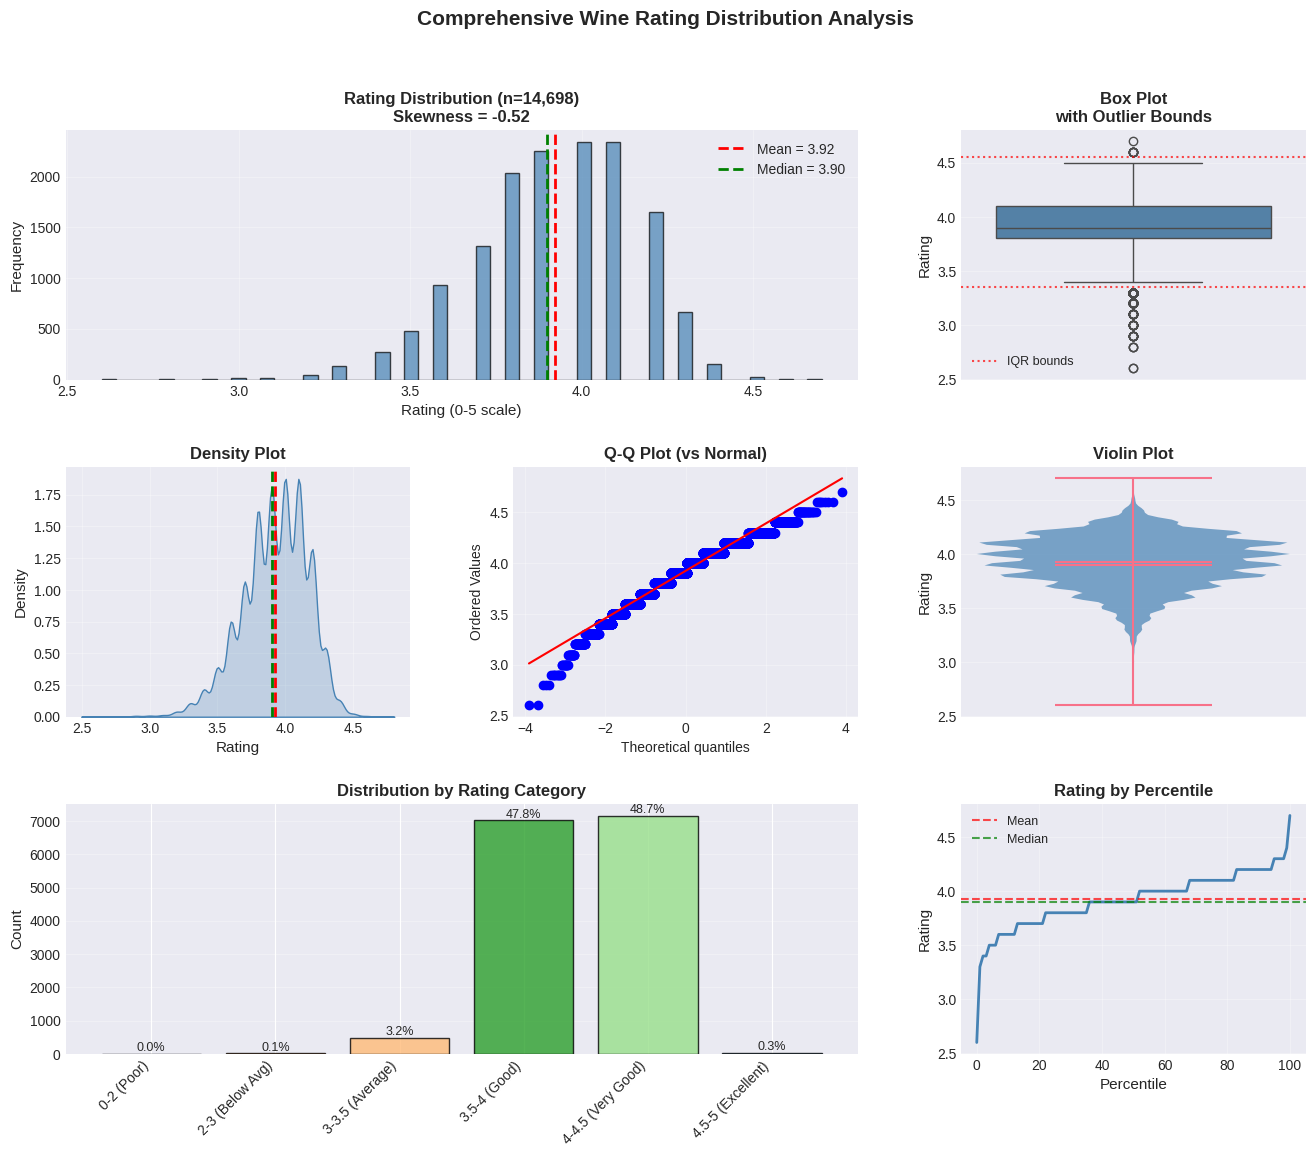


 Analysis complete!

📌 Key takeaway: Use vintage_rating as-is for modeling
   No transformation, no filtering - the data is already in good shape!


In [5]:
"""
Proper Wine Rating Distribution Analysis
==========================================
Target: vintage_rating (0-5 scale)
No transformation needed - ratings are already in bounded, interpretable scale
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assuming df is already loaded with y

print("=" * 80)
print("WINE RATING DISTRIBUTION ANALYSIS")
print("=" * 80)

# =============================================================================
# 1. BASIC STATISTICS
# =============================================================================
print("\nRating Statistics (Full Dataset):")
print(f"  Count:    {len(df):,} wines")
print(f"  Min:      {df['vintage_rating'].min():.2f}")
print(f"  Max:      {df['vintage_rating'].max():.2f}")
print(f"  Mean:     {df['vintage_rating'].mean():.2f}")
print(f"  Median:   {df['vintage_rating'].median():.2f}")
print(f"  Std Dev:  {df['vintage_rating'].std():.2f}")
print(f"  Skewness: {df['vintage_rating'].skew():.2f}")
print(f"  Kurtosis: {df['vintage_rating'].kurtosis():.2f}")

# =============================================================================
# 2. SKEWNESS INTERPRETATION
# =============================================================================
skewness = df['vintage_rating'].skew()
print(f"\nSkewness Interpretation:")
print(f"  Value: {skewness:.2f}")

if abs(skewness) < 0.5:
    skew_status = " SYMMETRIC - Excellent for modeling"
elif abs(skewness) < 1.0:
    skew_status = " MODERATELY SKEWED - Acceptable for modeling"
else:
    skew_status = " HIGHLY SKEWED - May need transformation"

if skewness < 0:
    direction = "LEFT-SKEWED (more high ratings)"
else:
    direction = "RIGHT-SKEWED (more low ratings)"

print(f"  Status: {skew_status}")
print(f"  Direction: {direction}")

# =============================================================================
# 3. PERCENTILE ANALYSIS
# =============================================================================
print(f"\nRating Percentiles:")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = df['vintage_rating'].quantile(p / 100)
    count_above = (df['vintage_rating'] >= value).sum()
    pct_above = (count_above / len(df)) * 100
    print(f"  P{p:2d}: {value:.2f}  ({count_above:6,} wines = {pct_above:5.1f}%)")

# =============================================================================
# 4. RATING DISTRIBUTION BY BINS
# =============================================================================
print(f"\n🎯 Distribution by Rating Bins:")
bins = [0, 2, 3, 3.5, 4, 4.5, 5.01]
labels = ['0-2 (Poor)', '2-3 (Below Avg)', '3-3.5 (Average)',
          '3.5-4 (Good)', '4-4.5 (Very Good)', '4.5-5 (Excellent)']
df['rating_category'] = pd.cut(df['vintage_rating'], bins=bins, labels=labels, right=False)

for label in labels:
    count = (df['rating_category'] == label).sum()
    pct = (count / len(df)) * 100
    print(f"  {label:20s}: {count:6,} wines ({pct:5.1f}%)")

# =============================================================================
# 5. OUTLIER DETECTION (using IQR method)
# =============================================================================
Q1 = df['vintage_rating'].quantile(0.25)
Q3 = df['vintage_rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_low = df[df['vintage_rating'] < lower_bound]
outliers_high = df[df['vintage_rating'] > upper_bound]

print(f"\n Outlier Analysis (IQR Method):")
print(f"  Q1 (25th percentile): {Q1:.2f}")
print(f"  Q3 (75th percentile): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Lower bound (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"  Upper bound (Q3 + 1.5*IQR): {upper_bound:.2f}")
print(f"  Low outliers (< {lower_bound:.2f}): {len(outliers_low):,}")
print(f"  High outliers (> {upper_bound:.2f}): {len(outliers_high):,}")
print(f"  Total outliers: {len(outliers_low) + len(outliers_high):,} ({(len(outliers_low) + len(outliers_high))/len(df)*100:.1f}%)")

# =============================================================================
# 6. NORMALITY TESTS
# =============================================================================
print(f"\n🔬 Normality Tests:")

# Shapiro-Wilk test (on sample if dataset is large)
if len(df) > 5000:
    sample = df['vintage_rating'].sample(5000, random_state=42)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
    print(f"  Shapiro-Wilk (n=5000 sample):")
else:
    shapiro_stat, shapiro_p = stats.shapiro(df['vintage_rating'])
    print(f"  Shapiro-Wilk:")

print(f"    Statistic: {shapiro_stat:.4f}")
print(f"    P-value: {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print(f"    Result:  Cannot reject normality (p > 0.05)")
else:
    print(f"    Result: ❌ Rejects normality (p < 0.05)")

# Kolmogorov-Smirnov test
ks_stat, ks_p = stats.kstest(df['vintage_rating'], 'norm',
                              args=(df['vintage_rating'].mean(), df['vintage_rating'].std()))
print(f"\n  Kolmogorov-Smirnov:")
print(f"    Statistic: {ks_stat:.4f}")
print(f"    P-value: {ks_p:.4e}")
if ks_p > 0.05:
    print(f"    Result:  Cannot reject normality (p > 0.05)")
else:
    print(f"    Result: ❌ Rejects normality (p < 0.05)")

# =============================================================================
# 7. DECISION FOR MODELING
# =============================================================================
print("\n" + "=" * 80)
print("🎯 MODELING RECOMMENDATIONS")
print("=" * 80)

print(f"\n USE ORIGINAL RATINGS (no transformation needed)")
print(f"\nReasons:")
print(f"  1. Ratings are on bounded 0-5 scale (already normalized)")
print(f"  2. Skewness = {skewness:.2f} is acceptable (-1 < skew < 1)")
print(f"  3. Distribution is moderately left-skewed (more good wines)")
print(f"  4. Outliers represent legitimate extreme ratings, not errors")
print(f"  5. Transformation would make predictions harder to interpret")

print(f"\nModeling Implications:")
print(f"  • Use vintage_rating as-is for regression target")
print(f"  • Consider robust regression models (e.g., Huber loss)")
print(f"  • Evaluate models with metrics appropriate for ratings:")
print(f"    - MAE (Mean Absolute Error) - interpretable in rating points")
print(f"    - RMSE (Root Mean Squared Error)")
print(f"    - R² score")
print(f"  • Keep ALL data points (don't filter by percentile)")

if abs(skewness) > 0.5:
    print(f"\n Optional: Some algorithms benefit from more symmetric data")
    print(f"     Consider tree-based models (Random Forest, XGBoost)")
    print(f"     which are robust to skewness without transformation")

print("=" * 80)

# =============================================================================
# 8. COMPREHENSIVE VISUALIZATION
# =============================================================================
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Row 1: Main distributions
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(df['vintage_rating'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['vintage_rating'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {df["vintage_rating"].mean():.2f}')
ax1.axvline(df['vintage_rating'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median = {df["vintage_rating"].median():.2f}')
ax1.set_xlabel('Rating (0-5 scale)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title(f'Rating Distribution (n={len(df):,})\nSkewness = {skewness:.2f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
sns.boxplot(y=df['vintage_rating'], ax=ax2, color='steelblue')
ax2.axhline(lower_bound, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label='IQR bounds')
ax2.axhline(upper_bound, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.set_ylabel('Rating', fontsize=11)
ax2.set_title('Box Plot\nwith Outlier Bounds', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Row 2: Density and QQ plot
ax3 = fig.add_subplot(gs[1, 0])
sns.kdeplot(data=df, x='vintage_rating', fill=True, ax=ax3, color='steelblue')
ax3.axvline(df['vintage_rating'].mean(), color='red', linestyle='--', linewidth=2)
ax3.axvline(df['vintage_rating'].median(), color='green', linestyle='--', linewidth=2)
ax3.set_xlabel('Rating', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('Density Plot', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
stats.probplot(df['vintage_rating'], dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot (vs Normal)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
# Violin plot
parts = ax5.violinplot([df['vintage_rating']], positions=[0], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.7)
ax5.set_ylabel('Rating', fontsize=11)
ax5.set_title('Violin Plot', fontsize=12, fontweight='bold')
ax5.set_xticks([])
ax5.grid(True, alpha=0.3, axis='y')

# Row 3: Categorical distribution and percentile curve
ax6 = fig.add_subplot(gs[2, :2])
category_counts = df['rating_category'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#1f77b4']
ax6.bar(range(len(category_counts)), category_counts.values,
        color=colors, edgecolor='black', alpha=0.8)
ax6.set_xticks(range(len(category_counts)))
ax6.set_xticklabels(category_counts.index, rotation=45, ha='right')
ax6.set_ylabel('Count', fontsize=11)
ax6.set_title('Distribution by Rating Category', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
# Add percentages on bars
for i, v in enumerate(category_counts.values):
    pct = v / len(df) * 100
    ax6.text(i, v, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

ax7 = fig.add_subplot(gs[2, 2])
percentile_range = range(0, 101, 1)
percentile_values = [df['vintage_rating'].quantile(p / 100) for p in percentile_range]
ax7.plot(percentile_range, percentile_values, linewidth=2, color='steelblue')
ax7.axhline(df['vintage_rating'].mean(), color='red', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Mean')
ax7.axhline(df['vintage_rating'].median(), color='green', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Median')
ax7.set_xlabel('Percentile', fontsize=11)
ax7.set_ylabel('Rating', fontsize=11)
ax7.set_title('Rating by Percentile', fontsize=12, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3)

fig.suptitle('Comprehensive Wine Rating Distribution Analysis',
             fontsize=15, fontweight='bold')
#plt.savefig('./results/plots/rating_analysis.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n Analysis complete!")
print(f"\n📌 Key takeaway: Use vintage_rating as-is for modeling")
print(f"   No transformation, no filtering - the data is already in good shape!")

# 3 . INDIVIDUAL FEATURE

Identifier :

wine                     object

winery                   object

Numerical cat:

vintage_year            float64

vintage_rating          float64

vintage_rating_count      int64

structure_acidity       float64

structure_intensity     float64

structure_sweetness     float64

structure_tannin        float64

categorical cat :

region                   object

grapes                   object

%% md
### 3.1.1 vintage_year            float64
One could expect that older wine get better rating, however datas should a weak correlation of year with rating. Several explanation : wine that can age are mixed with those who are those that cannot . I think that vivino process the rating has the mean of all the evaluation, which thus lower the effect aging wine with the rating of when the wine was younger.




Correlation (Vintage Year vs Rating): -0.083
   ⚠ Weak correlation (-0.083)
   → Vintage year has limited impact on rating

Correlation (Vintage Year vs Rating price<60€): -0.083
   ✓ Negative correlation (-0.083)
   → Older vintages command premium ratings (aging value)


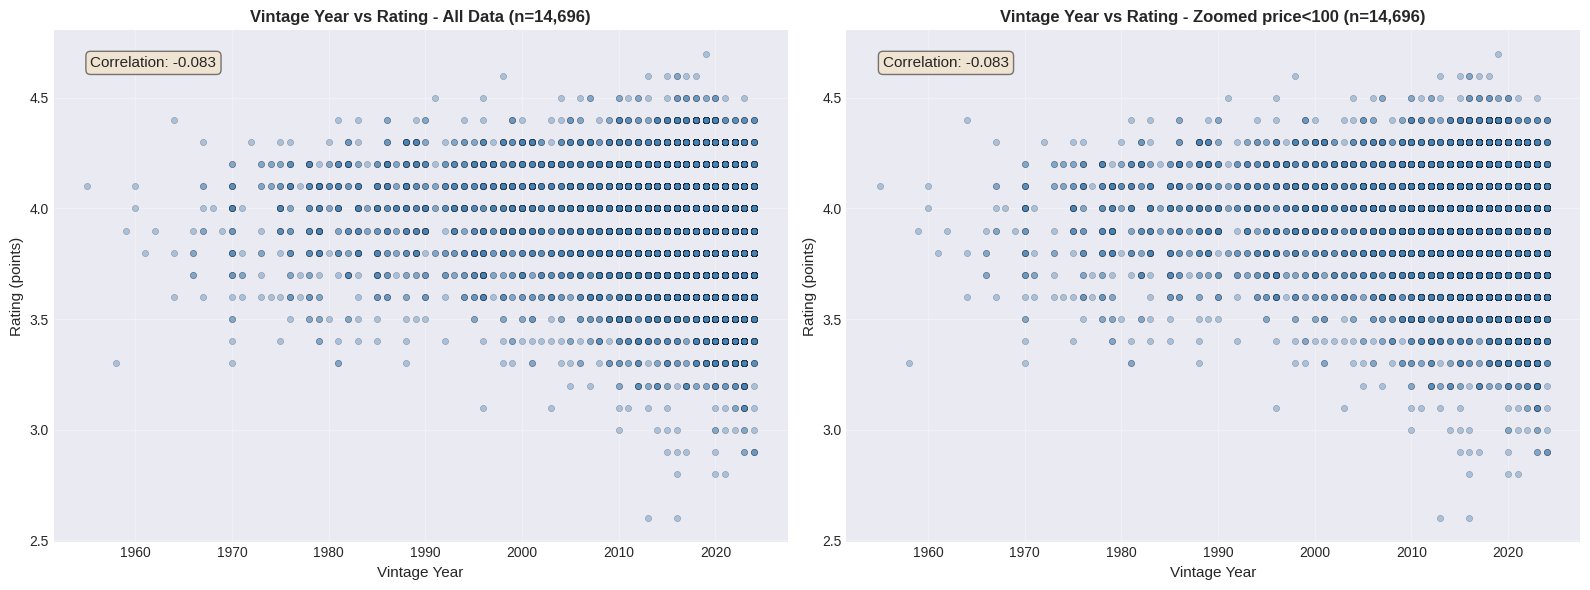

In [6]:
def coor_insight(corr_vintage_rating):
    print(f"\nINSIGHT:")
    if corr_vintage_rating > 0.2:
        print(f"   ✓ Positive correlation ({corr_vintage_rating:.3f})")
        print(f"   → Newer vintages tend to be ratingd higher")
    elif corr_vintage_rating < -0.2:
        print(f"   ✓ Negative correlation ({corr_vintage_rating:.3f})")
        print(f"   → Older vintages command premium ratings (aging value)")
    else:
        print(f"   ⚠ Weak correlation ({corr_vintage_rating:.3f})")
        print(f"   → Vintage year has limited impact on rating")


# Filter valid data
df_q2 = df[(df['vintage_year'] > 1950) & (df['vintage_rating'] > 0)]
df_q2_zoom = df[(df['vintage_year'] > 1950) & (df['price_availability'] < 100)]

# Calculate correlation
corr_vintage_rating = df_q2['vintage_year'].corr(df_q2['vintage_rating'])
print(f"\nCorrelation (Vintage Year vs Rating): {corr_vintage_rating:.3f}")
print(f"   ⚠ Weak correlation ({corr_vintage_rating:.3f})")
print(f"   → Vintage year has limited impact on rating")

corr_vintage_rating_zoom = df_q2_zoom['vintage_year'].corr(df_q2_zoom['vintage_rating'])
print(f"\nCorrelation (Vintage Year vs Rating price<60€): {corr_vintage_rating_zoom:.3f}")
print(f"   ✓ Negative correlation ({corr_vintage_rating_zoom:.3f})")
print(f"   → Older vintages command premium ratings (aging value)")
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full dataset
axes[0].scatter(df_q2['vintage_year'], df_q2['vintage_rating'],
                alpha=0.4, s=20, color='steelblue', edgecolors='k', linewidth=0.3)
axes[0].set_xlabel('Vintage Year', fontsize=11)
axes[0].set_ylabel('Rating (points)', fontsize=11)
axes[0].set_title(f'Vintage Year vs Rating - All Data (n={len(df_q2):,})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'Correlation: {corr_vintage_rating:.3f}',
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Zoomed
corr_zoom = df_q2_zoom['vintage_year'].corr(df_q2_zoom['vintage_rating'])
axes[1].scatter(df_q2_zoom['vintage_year'], df_q2_zoom['vintage_rating'],
                alpha=0.4, s=20, color='steelblue', edgecolors='k', linewidth=0.3)
axes[1].set_xlabel('Vintage Year', fontsize=11)
axes[1].set_ylabel('Rating (points)', fontsize=11)
axes[1].set_title(f'Vintage Year vs Rating - Zoomed price<100 (n={len(df_q2_zoom):,})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, f'Correlation: {corr_vintage_rating_zoom:.3f}',
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
#plt.savefig('./results/plots/year_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
"""
Check for potential data leakage: same wine name across train/val/test splits
"""

import pandas as pd
import numpy as np

print("=" * 80)
print("🔍 CHECKING FOR WINE NAME LEAKAGE")
print("=" * 80)

# Load data
df = pd.read_csv('../data/france_wines_type1_clean.csv')
df = df[df['price_availability'] < 100]

# Create wine identifier (without vintage year)
df['wine_id_no_year'] = df['wine'] + '_' + df['winery']

print(f"\n📊 Dataset info:")
print(f"   Total wines: {len(df):,}")
print(f"   Unique wine names (with year): {df['wine'].nunique():,}")
print(f"   Unique wine+winery combos (no year): {df['wine_id_no_year'].nunique():,}")

# Simulate your split (60/20/20)
from sklearn.model_selection import train_test_split

features_to_drop = [
    'wine', 'winery', 'price_availability', 'vintage_rating_count',
    'grapes', 'structure_intensity', 'structure_sweetness'
]
df_selected = df.drop(columns=features_to_drop)

y = df_selected['vintage_rating']
X = df_selected.drop(columns=['vintage_rating'])

# Keep wine_id_no_year for analysis
wine_ids = df['wine_id_no_year'].values

X_temp, X_test, y_temp, y_test, ids_temp, ids_test = train_test_split(
    X, y, wine_ids, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_temp, y_temp, ids_temp, test_size=0.25, random_state=42
)

print(f"\n✂️  Split sizes:")
print(f"   Train: {len(ids_train):,}")
print(f"   Val:   {len(ids_val):,}")
print(f"   Test:  {len(ids_test):,}")

# Check for leakage
unique_train = set(ids_train)
unique_val = set(ids_val)
unique_test = set(ids_test)

leak_val = unique_val & unique_train
leak_test = unique_test & unique_train
leak_val_test = unique_val & unique_test

print("\n" + "=" * 80)
print("🚨 LEAKAGE ANALYSIS")
print("=" * 80)

print(f"\n📍 Unique wine names:")
print(f"   In train: {len(unique_train):,}")
print(f"   In val:   {len(unique_val):,}")
print(f"   In test:  {len(unique_test):,}")

print(f"\n⚠️  LEAKAGE (same wine name in multiple sets):")
print(f"   Train → Val:  {len(leak_val):,} wines ({len(leak_val)/len(unique_val)*100:.1f}% of val)")
print(f"   Train → Test: {len(leak_test):,} wines ({len(leak_test)/len(unique_test)*100:.1f}% of test)")
print(f"   Val → Test:   {len(leak_val_test):,} wines")

# Find examples
if len(leak_test) > 0:
    print("\n" + "=" * 80)
    print("📋 EXAMPLES OF LEAKED WINES (Train → Test)")
    print("=" * 80)

    examples = list(leak_test)[:10]
    for wine_id in examples:
        # Get all instances of this wine
        wine_data = df[df['wine_id_no_year'] == wine_id][['wine', 'winery', 'vintage_year', 'vintage_rating']]

        print(f"\n🍷 {wine_id}")

        # Which years are in train vs test?
        years_train = df[(df['wine_id_no_year'] == wine_id) &
                         (df.index.isin(X_train.index))]['vintage_year'].values
        years_test = df[(df['wine_id_no_year'] == wine_id) &
                        (df.index.isin(X_test.index))]['vintage_year'].values

        ratings_train = df[(df['wine_id_no_year'] == wine_id) &
                          (df.index.isin(X_train.index))]['vintage_rating'].values
        ratings_test = df[(df['wine_id_no_year'] == wine_id) &
                         (df.index.isin(X_test.index))]['vintage_rating'].values

        print(f"   Train years: {sorted(years_train)} → ratings: {[f'{r:.2f}' for r in ratings_train]}")
        print(f"   Test years:  {sorted(years_test)} → ratings: {[f'{r:.2f}' for r in ratings_test]}")
        print(f"   Rating variance: {wine_data['vintage_rating'].std():.3f}")

# Calculate impact
print("\n" + "=" * 80)
print("📊 IMPACT ASSESSMENT")
print("=" * 80)

# For leaked wines, compare rating variance
leaked_wines = list(leak_test)[:100]  # Sample
variances = []
for wine_id in leaked_wines:
    wine_ratings = df[df['wine_id_no_year'] == wine_id]['vintage_rating']
    if len(wine_ratings) > 1:
        variances.append(wine_ratings.std())

if variances:
    print(f"\n🎯 For leaked wines (same wine in train & test):")
    print(f"   Avg rating variance across years: {np.mean(variances):.4f}")
    print(f"   Median rating variance: {np.median(variances):.4f}")
    print(f"   Max rating variance: {np.max(variances):.4f}")
    print(f"\n💡 If variance is low (~0.1), model has easy time predicting test!")
    print(f"   If variance is high (~0.5+), different years vary significantly")

print("\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE")
print("=" * 80)
print("\n💡 Interpretation:")
print("   - High leakage (>50%) + Low variance → Model may overfit to wine names")
print("   - High leakage + High variance → Different years vary, leakage less critical")
print("   - Low leakage (<20%) → Split is more robust")

🔍 CHECKING FOR WINE NAME LEAKAGE

📊 Dataset info:
   Total wines: 14,698
   Unique wine names (with year): 6,494
   Unique wine+winery combos (no year): 9,989

✂️  Split sizes:
   Train: 8,818
   Val:   2,940
   Test:  2,940

🚨 LEAKAGE ANALYSIS

📍 Unique wine names:
   In train: 6,793
   In val:   2,619
   In test:  2,627

⚠️  LEAKAGE (same wine name in multiple sets):
   Train → Val:  941 wines (35.9% of val)
   Train → Test: 931 wines (35.4% of test)
   Val → Test:   451 wines

📋 EXAMPLES OF LEAKED WINES (Train → Test)

🍷 Moulin-à-Vent en Mortperay_A.F. Gros
   Train years: [2018.0, 2020.0, 2023.0] → ratings: ['4.00', '4.10', '4.00']
   Test years:  [2021.0] → ratings: ['4.10']
   Rating variance: 0.058

🍷 Châteauneuf-du-Pape Cuvèe Speciale Les Hautes Brusquières_Domaine de la Charbonnière
   Train years: [2001.0, 2019.0] → ratings: ['4.30', '4.30']
   Test years:  [2022.0] → ratings: ['4.20']
   Rating variance: 0.058

🍷 Haut-Médoc_Château Lachesnaye
   Train years: [1988.0] → ratin

### 3.1.2 vintage_rating_count      int64
The analysis plot show moderate correlation with rating, but i will likely drop it anyway considering you want to estimate the rating of the wine based on its characteristic not its review count on vivino. Funnily i was expecting a high count would somehow correl with lower rating but it's not the case




Correlation (Rating Count vs Rating): 0.017

INSIGHT:
   ⚠ Weak correlation (0.017)
   → Rating Count has limited impact on rating

Correlation (Rating Count vs Rating<385pts (q95%)): 0.017

INSIGHT:
   ⚠ Weak correlation (0.017)
   → Rating Count has limited impact on rating


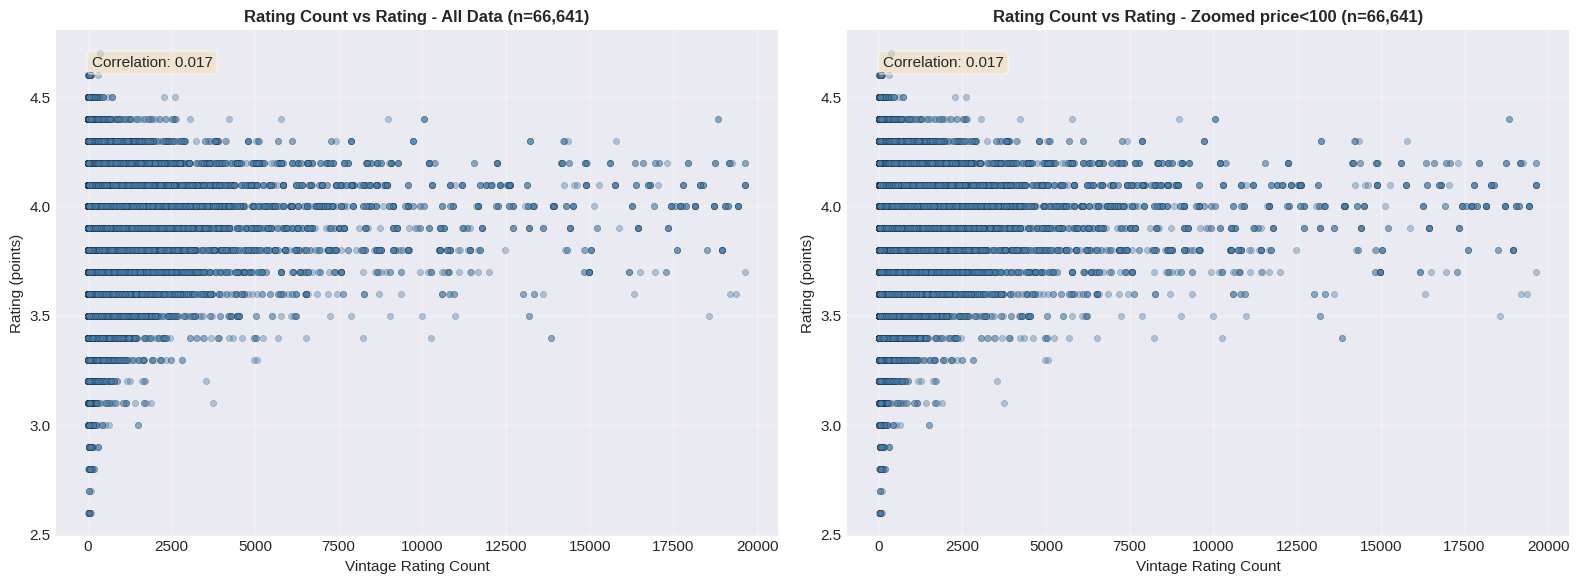

In [158]:

# %% md

# %%
# Insight function
def corr_insight(corr_value, var_name):
    print(f"\nINSIGHT:")
    if corr_value > 0.2:
        print(f"   ✓ Positive correlation ({corr_value:.3f})")
        print(f"   → Higher {var_name} tends to indicate higher ratings")
    elif corr_value < -0.2:
        print(f"   ✓ Negative correlation ({corr_value:.3f})")
        print(f"   → Higher {var_name} associated with lower ratings")
    else:
        print(f"   ⚠ Weak correlation ({corr_value:.3f})")
        print(f"   → {var_name} has limited impact on rating")


# Filter valid data
df_q3 = df[(df['vintage_rating_count'] < 20000)]
df_q3_zoom = df[(df['vintage_rating_count'] < 20000) & (df['price_availability']<100)]

# Calculate correlation
corr_rating_count_rating = df_q3['vintage_rating_count'].corr(df_q3['vintage_rating'])
print(f"\nCorrelation (Rating Count vs Rating): {corr_rating_count_rating:.3f}")
corr_insight(corr_rating_count_rating, "Rating Count")

corr_rating_count_rating_zoom = df_q3_zoom['vintage_rating_count'].corr(df_q3_zoom['vintage_rating'])
print(f"\nCorrelation (Rating Count vs Rating<385pts (q95%)): {corr_rating_count_rating_zoom:.3f}")
corr_insight(corr_rating_count_rating_zoom, "Rating Count")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full dataset
axes[0].scatter(df_q3['vintage_rating_count'], df_q3['vintage_rating'],
                alpha=0.4, s=20, color='steelblue', edgecolors='k', linewidth=0.3)
axes[0].set_xlabel('Vintage Rating Count', fontsize=11)
axes[0].set_ylabel('Rating (points)', fontsize=11)
axes[0].set_title(f'Rating Count vs Rating - All Data (n={len(df_q3):,})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'Correlation: {corr_rating_count_rating:.3f}',
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Zoomed
axes[1].scatter(df_q3_zoom['vintage_rating_count'], df_q3_zoom['vintage_rating'],
                alpha=0.4, s=20, color='steelblue', edgecolors='k', linewidth=0.3)
axes[1].set_xlabel('Vintage Rating Count', fontsize=11)
axes[1].set_ylabel('Rating (points)', fontsize=11)
axes[1].set_title(f'Rating Count vs Rating - Zoomed price<100 (n={len(df_q3_zoom):,})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, f'Correlation: {corr_rating_count_rating_zoom:.3f}',
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()



### 3.1.4  Feature Analysis: Price vs Rating (SIMPLIFIED VERSION)
Globally the price is a strong indicator for the rating, the more expensive the better rating, but looking at the dispersion, it can be a misleading.


🔍 FEATURE ANALYSIS: Price vs Rating
Dataset: 66,834 valid wines
   Price range: $4.00 - $99.99
   Rating range: 2.60 - 4.70

1️⃣ CORRELATION ANALYSIS

Pearson Correlation: r = 0.5578
   p-value: 0.00e+00
    Highly significant (p < 0.001)

Interpretation:
    STRONG correlation - rating strongly influences price

2️⃣ SEGMENTATION ANALYSIS

Average Price by Rating Segment:
   Poor (<2.5)         : $   nan (median: $   nan, n=0)
   Average (2.5-3.5)   : $ 17.99 (median: $ 13.39, n=4,424)
   Good (3.5-4.0)      : $ 31.71 (median: $ 25.63, n=40,543)
   Excellent (>4.0)    : $ 56.00 (median: $ 54.50, n=21,867)

Average Rating by Price Segment:
   Budget (<$10)       : 3.62 (median: 3.60, n=4,401)
   Mid ($10-20)        : 3.77 (median: 3.80, n=14,916)
   Premium ($20-50)    : 3.94 (median: 4.00, n=28,239)
   Luxury (>$50)       : 4.08 (median: 4.10, n=19,278)

3️⃣ REGRESSION MODELS

Model 1: Price = f(Rating) [Linear]
   Equation: Price = 57.26 × Rating + -185.86
   R² = 0.3111 → Rating exp

/tmp/ipykernel_54412/3817079724.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_price_stats = df_analysis.groupby('rating_segment')['price_availability'].agg(['mean', 'median', 'count'])
/tmp/ipykernel_54412/3817079724.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating_stats = df_analysis.groupby('price_segment')['vintage_rating'].agg(['mean', 'median', 'count'])
/tmp/ipykernel_54412/3817079724.py:198: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

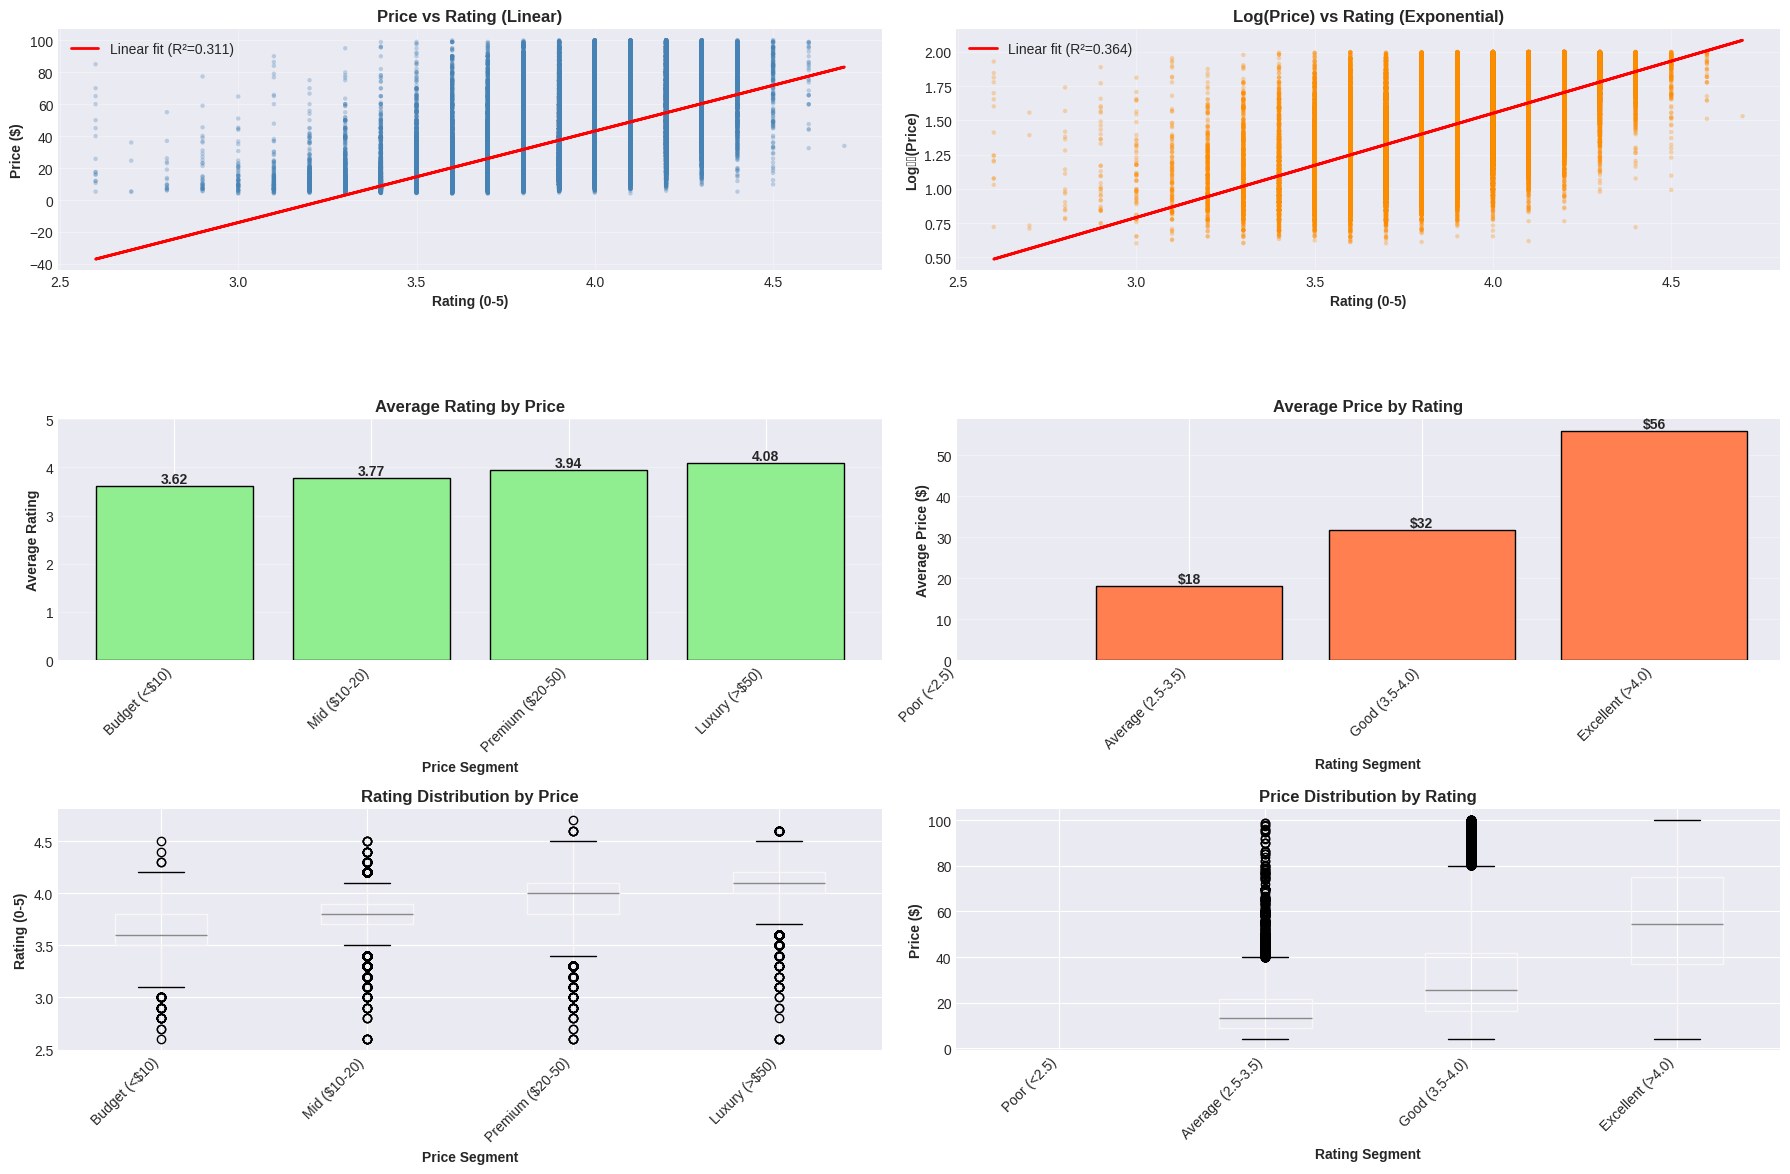


5️ SUMMARY

CORRELATION STRENGTH:
   STRONG correlation (r=0.558)

PREDICTIVE POWER:
   MODERATE - Rating explains 36% of price variation

FINAL CONCLUSION:
   Rating is a STRONG predictor of price
      Higher ratings consistently mean higher prices

 Analysis Complete!


In [10]:
# ### Feature Analysis: Price vs Rating (SIMPLIFIED VERSION)
print("\n🔍 FEATURE ANALYSIS: Price vs Rating")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Assume df exists with columns: 'price_availability', 'vintage_rating'
# Filter valid data
df_analysis = df[(df['price_availability'] < 100) &
                 (df['vintage_rating'] >= 0) & 
                 (df['vintage_rating'] <= 5)].copy()

print(f"Dataset: {len(df_analysis):,} valid wines")
print(f"   Price range: ${df_analysis['price_availability'].min():.2f} - ${df_analysis['price_availability'].max():.2f}")
print(f"   Rating range: {df_analysis['vintage_rating'].min():.2f} - {df_analysis['vintage_rating'].max():.2f}")

# ============================================================================
# SECTION 1: BASIC CORRELATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("1️⃣ CORRELATION ANALYSIS")
print("="*80)

# Pearson correlation (linear relationship)
corr_pearson = df_analysis['price_availability'].corr(df_analysis['vintage_rating'], method='pearson')
print(f"\nPearson Correlation: r = {corr_pearson:.4f}")

# Statistical significance test
stat_result = stats.pearsonr(df_analysis['price_availability'], df_analysis['vintage_rating'])
print(f"   p-value: {stat_result[1]:.2e}")
if stat_result[1] < 0.001:
    print(f"    Highly significant (p < 0.001)")

# Interpretation
print(f"\nInterpretation:")
if abs(corr_pearson) > 0.5:
    print(f"    STRONG correlation - rating strongly influences price")
elif abs(corr_pearson) > 0.3:
    print(f"    MODERATE correlation - rating influences price but other factors matter")
elif abs(corr_pearson) > 0.1:
    print(f"    WEAK correlation - rating has little impact on price")
else:
    print(f"   ❌ NO correlation - rating doesn't predict price")

# ============================================================================
# SECTION 2: SEGMENTATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("2️⃣ SEGMENTATION ANALYSIS")
print("="*80)

# Rating segments
df_analysis['rating_segment'] = pd.cut(df_analysis['vintage_rating'],
                                       bins=[0, 2.5, 3.5, 4.0, 5.0],
                                       labels=['Poor (<2.5)', 'Average (2.5-3.5)',
                                              'Good (3.5-4.0)', 'Excellent (>4.0)'])

# Price segments
df_analysis['price_segment'] = pd.cut(df_analysis['price_availability'],
                                      bins=[0, 10, 20, 50, df_analysis['price_availability'].max()],
                                      labels=['Budget (<$10)', 'Mid ($10-20)',
                                             'Premium ($20-50)', 'Luxury (>$50)'])

print(f"\nAverage Price by Rating Segment:")
rating_price_stats = df_analysis.groupby('rating_segment')['price_availability'].agg(['mean', 'median', 'count'])
for segment in rating_price_stats.index:
    mean_p = rating_price_stats.loc[segment, 'mean']
    median_p = rating_price_stats.loc[segment, 'median']
    count_p = int(rating_price_stats.loc[segment, 'count'])
    print(f"   {segment:20s}: ${mean_p:6.2f} (median: ${median_p:6.2f}, n={count_p:,})")

print(f"\nAverage Rating by Price Segment:")
price_rating_stats = df_analysis.groupby('price_segment')['vintage_rating'].agg(['mean', 'median', 'count'])
for segment in price_rating_stats.index:
    mean_r = price_rating_stats.loc[segment, 'mean']
    median_r = price_rating_stats.loc[segment, 'median']
    count_r = int(price_rating_stats.loc[segment, 'count'])
    print(f"   {segment:20s}: {mean_r:.2f} (median: {median_r:.2f}, n={count_r:,})")

# ============================================================================
# SECTION 3: REGRESSION MODELS
# ============================================================================
print("\n" + "="*80)
print("3️⃣ REGRESSION MODELS")
print("="*80)

# Model 1: Rating predicts Price (LINEAR)
X1 = df_analysis['vintage_rating'].values.reshape(-1, 1)
y1 = df_analysis['price_availability'].values

model1 = LinearRegression()
model1.fit(X1, y1)
y1_pred = model1.predict(X1)

r2_1 = r2_score(y1, y1_pred)
mae_1 = mean_absolute_error(y1, y1_pred)

print(f"\nModel 1: Price = f(Rating) [Linear]")
print(f"   Equation: Price = {model1.coef_[0]:.2f} × Rating + {model1.intercept_:.2f}")
print(f"   R² = {r2_1:.4f} → Rating explains {r2_1*100:.1f}% of price variation")
print(f"   Average error: ±${mae_1:.2f}")

print(f"\n   What this means:")
print(f"      • Each +1 rating point → +${model1.coef_[0]:.2f} in price")
print(f"      • 3.0-rated wine → predicted price: ${model1.predict([[3.0]])[0]:.2f}")
print(f"      • 4.0-rated wine → predicted price: ${model1.predict([[4.0]])[0]:.2f}")

# Model 2: Rating predicts Log(Price) - for wines where price grows exponentially
df_analysis['log_price'] = np.log10(df_analysis['price_availability'])
X2 = df_analysis['vintage_rating'].values.reshape(-1, 1)
y2 = df_analysis['log_price'].values

model2 = LinearRegression()
model2.fit(X2, y2)
y2_pred = model2.predict(X2)

r2_2 = r2_score(y2, y2_pred)

# Convert predictions back to original scale for error
y2_pred_original = 10 ** y2_pred
y2_original = df_analysis['price_availability'].values
mae_2 = mean_absolute_error(y2_original, y2_pred_original)

print(f"\nModel 2: Log(Price) = f(Rating) [Exponential growth]")
print(f"   R² = {r2_2:.4f} → Rating explains {r2_2*100:.1f}% of log(price) variation")
print(f"   Average error: ±${mae_2:.2f}")

multiplier = 10 ** model2.coef_[0]
print(f"\n   What this means:")
print(f"      • Each +1 rating point → price ×{multiplier:.2f}")
print(f"      • 3.0-rated wine → predicted price: ${10**model2.predict([[3.0]])[0]:.2f}")
print(f"      • 4.0-rated wine → predicted price: ${10**model2.predict([[4.0]])[0]:.2f}")

print(f"\n🎯 Best Model:")
if r2_2 > r2_1 + 0.03:
    print(f"    EXPONENTIAL model is better (R²={r2_2:.4f} vs {r2_1:.4f})")
    print(f"      → Price grows EXPONENTIALLY with rating")
    print(f"      → Higher ratings have multiplicative impact on price")
elif r2_1 > r2_2 + 0.03:
    print(f"    LINEAR model is better (R²={r2_1:.4f} vs {r2_2:.4f})")
    print(f"      → Price grows LINEARLY with rating")
    print(f"      → Each rating point adds a fixed amount to price")
else:
    print(f"    Both models perform similarly")
    print(f"      → The relationship is somewhere between linear and exponential")

# ============================================================================
# SECTION 4: VISUALIZATIONS (6 most important plots)
# ============================================================================
print("\n" + "="*80)
print("4GENERATING VISUALIZATIONS...")
print("="*80)

fig = plt.figure(figsize=(18, 12))

# Plot [0,0]: Raw Price vs Rating (scatter + linear regression)
ax1 = plt.subplot(3, 2, 1)
ax1.scatter(df_analysis['vintage_rating'], df_analysis['price_availability'],
           alpha=0.3, s=10, color='steelblue', edgecolors='none')
ax1.plot(df_analysis['vintage_rating'], y1_pred, 'r-', linewidth=2,
        label=f'Linear fit (R²={r2_1:.3f})')
ax1.set_xlabel('Rating (0-5)', fontweight='bold')
ax1.set_ylabel('Price ($)', fontweight='bold')
ax1.set_title('Price vs Rating (Linear)', fontweight='bold', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot [1,0]: Log Price vs Rating (shows exponential relationship better)
ax2 = plt.subplot(3, 2, 2)
ax2.scatter(df_analysis['vintage_rating'], df_analysis['log_price'],
           alpha=0.3, s=10, color='darkorange', edgecolors='none')
ax2.plot(df_analysis['vintage_rating'], y2_pred, 'r-', linewidth=2,
        label=f'Linear fit (R²={r2_2:.3f})')
ax2.set_xlabel('Rating (0-5)', fontweight='bold')
ax2.set_ylabel('Log₁₀(Price)', fontweight='bold')
ax2.set_title('Log(Price) vs Rating (Exponential)', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot [2,0]: Box plot - Price by Rating Segment
ax3 = plt.subplot(3, 2, 6)
rating_segments_order = ['Poor (<2.5)', 'Average (2.5-3.5)', 'Good (3.5-4.0)', 'Excellent (>4.0)']
df_analysis.boxplot(column='price_availability', by='rating_segment', ax=ax3,
                    positions=range(len(rating_segments_order)))
ax3.set_xlabel('Rating Segment', fontweight='bold')
ax3.set_ylabel('Price ($)', fontweight='bold')
ax3.set_title('Price Distribution by Rating', fontweight='bold', fontsize=12)
ax3.set_xticklabels(rating_segments_order, rotation=45, ha='right')
plt.suptitle('')  # Remove automatic title

# Plot [0,1]: Average Price by Rating (bar chart)
ax4 = plt.subplot(3, 2, 4)
rating_means = df_analysis.groupby('rating_segment')['price_availability'].mean().reindex(rating_segments_order)
bars = ax4.bar(range(len(rating_means)), rating_means.values, color='coral', edgecolor='black')
ax4.set_xlabel('Rating Segment', fontweight='bold')
ax4.set_ylabel('Average Price ($)', fontweight='bold')
ax4.set_title('Average Price by Rating', fontweight='bold', fontsize=12)
ax4.set_xticks(range(len(rating_means)))
ax4.set_xticklabels(rating_means.index, rotation=45, ha='right')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.0f}', ha='center', va='bottom', fontweight='bold')

# Plot [1,1]: Box plot - Rating by Price Segment
ax5 = plt.subplot(3,2, 5)
price_segments_order = ['Budget (<$10)', 'Mid ($10-20)', 'Premium ($20-50)', 'Luxury (>$50)']
df_analysis.boxplot(column='vintage_rating', by='price_segment', ax=ax5,
                    positions=range(len(price_segments_order)))
ax5.set_xlabel('Price Segment', fontweight='bold')
ax5.set_ylabel('Rating (0-5)', fontweight='bold')
ax5.set_title('Rating Distribution by Price', fontweight='bold', fontsize=12)
ax5.set_xticklabels(price_segments_order, rotation=45, ha='right')
plt.suptitle('')

# Plot [2,1]: Average Rating by Price (bar chart)
ax6 = plt.subplot(3,2, 3)
price_means = df_analysis.groupby('price_segment')['vintage_rating'].mean().reindex(price_segments_order)
bars = ax6.bar(range(len(price_means)), price_means.values, color='lightgreen', edgecolor='black')
ax6.set_xlabel('Price Segment', fontweight='bold')
ax6.set_ylabel('Average Rating', fontweight='bold')
ax6.set_title('Average Rating by Price', fontweight='bold', fontsize=12)
ax6.set_xticks(range(len(price_means)))
ax6.set_xticklabels(price_means.index, rotation=45, ha='right')
ax6.set_ylim(0, 5)
ax6.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
#plt.savefig('./results/plots/price_vs_rating.png', dpi=300, bbox_inches='tight')

plt.show()

# ============================================================================
# SECTION 5: SUMMARY
# ============================================================================
print("\n" + "="*80)
print("5️ SUMMARY")
print("="*80)

print(f"\nCORRELATION STRENGTH:")
if abs(corr_pearson) > 0.5:
    print(f"   STRONG correlation (r={corr_pearson:.3f})")
elif abs(corr_pearson) > 0.3:
    print(f"    MODERATE correlation (r={corr_pearson:.3f})")
elif abs(corr_pearson) > 0.1:
    print(f"   WEAK correlation (r={corr_pearson:.3f})")
else:
    print(f"   VERY WEAK/NO correlation (r={corr_pearson:.3f})")

print(f"\nPREDICTIVE POWER:")
best_r2 = max(r2_1, r2_2)
if best_r2 > 0.5:
    print(f"   GOOD - Rating explains {best_r2*100:.0f}% of price variation")
elif best_r2 > 0.3:
    print(f"   MODERATE - Rating explains {best_r2*100:.0f}% of price variation")
elif best_r2 > 0.1:
    print(f"   WEAK - Rating explains only {best_r2*100:.0f}% of price variation")
else:
    print(f"   POOR - Rating explains only {best_r2*100:.0f}% of price variation")

print(f"\nFINAL CONCLUSION:")
if corr_pearson > 0.4 and best_r2 > 0.3:
    print(f"   Rating is a STRONG predictor of price")
    print(f"      Higher ratings consistently mean higher prices")
elif corr_pearson > 0.2 and best_r2 > 0.15:
    print(f"   Rating is a MODERATE predictor of price")
    print(f"      Rating matters, but other factors also important")
    print(f"      (region, brand, vintage year, etc.)")
else:
    print(f"  Rating is a WEAK predictor of price")
    print(f"      Price depends more on other factors than rating")
    print(f"      (brand prestige, scarcity, region, marketing, etc.)")

print("\n" + "="*80)
print(" Analysis Complete!")
print("="*80)


### 3.1.4 structure_acidity, structure_intensity, structure_sweetness, structure_tannin     float64
Across all characteristics, the data shows a generally homogeneous, roughly Gaussian distribution centered around an offset near 3.6.
 Red wines tend :
- to be more acidic than soft
- more intense than light,
- slightly skewed toward the tannic side,
- and predominantly dry — as expected for this wine type.

The 3D visualization shows three structural clusters:
Cluster 1 (low structure): intensity/tannin ~1–2.5, acidity ~1.5–2.5
Cluster 2 (medium structure): intensity/tannin ~2.5–4, acidity ~3–4
Cluster 3 (high structure): intensity/tannin ~3.5–5, acidity ~3.5–4.5

Clusters are internally cohesive, with intensity and tannin strongly correlated. Despite structural differences, vintage ratings (color gradient) span the full range (2.5–4.8) in all clusters, meaning wines of any structure can achieve high or low ratings.

Conclusion: While the structural differences are clear and meaningful for categorizing wine styles, these features show weak predictive power for rating and would likely contribute limited value in feature engineering for a rating prediction model.



🔍 Q6: Les caractéristiques structurelles influencent-elles la note ?
--------------------------------------------------------------------------------
Available structure features: structure_acidity, structure_intensity, structure_sweetness, structure_tannin
Valid data points: 66,834 wines
Rating range: 2.60 - 4.70
Average rating: 3.92 ± 0.24

Pearson Correlations with Rating:
   structure_acidity        : Pearson=-0.055 | Spearman=-0.036
   structure_intensity      : Pearson= 0.007 | Spearman= 0.031
   structure_sweetness      : Pearson=-0.086 | Spearman=-0.095
   structure_tannin         : Pearson=-0.144 | Spearman=-0.138

Rating Segmentation Analysis:

   Acidity:
      Poor (<2.5)         : nan ± nan (n=0)
      Average (2.5-3.5)   : 4.00 ± 0.42 (n=4424)
      Good (3.5-4.0)      : 3.95 ± 0.50 (n=40543)
      Excellent (>4.0)    : 3.91 ± 0.52 (n=21867)

   Intensity:
      Poor (<2.5)         : nan ± nan (n=0)
      Average (2.5-3.5)   : 3.68 ± 0.88 (n=4424)
      Good (3.5-4.0)   

/tmp/ipykernel_54412/1979246868.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_stats = df_q6.groupby('rating_segment')[available_features].agg(['mean', 'std', 'count'])
/tmp/ipykernel_54412/1979246868.py:147: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_means = df_q6.groupby('rating_segment')[available_features].mean()


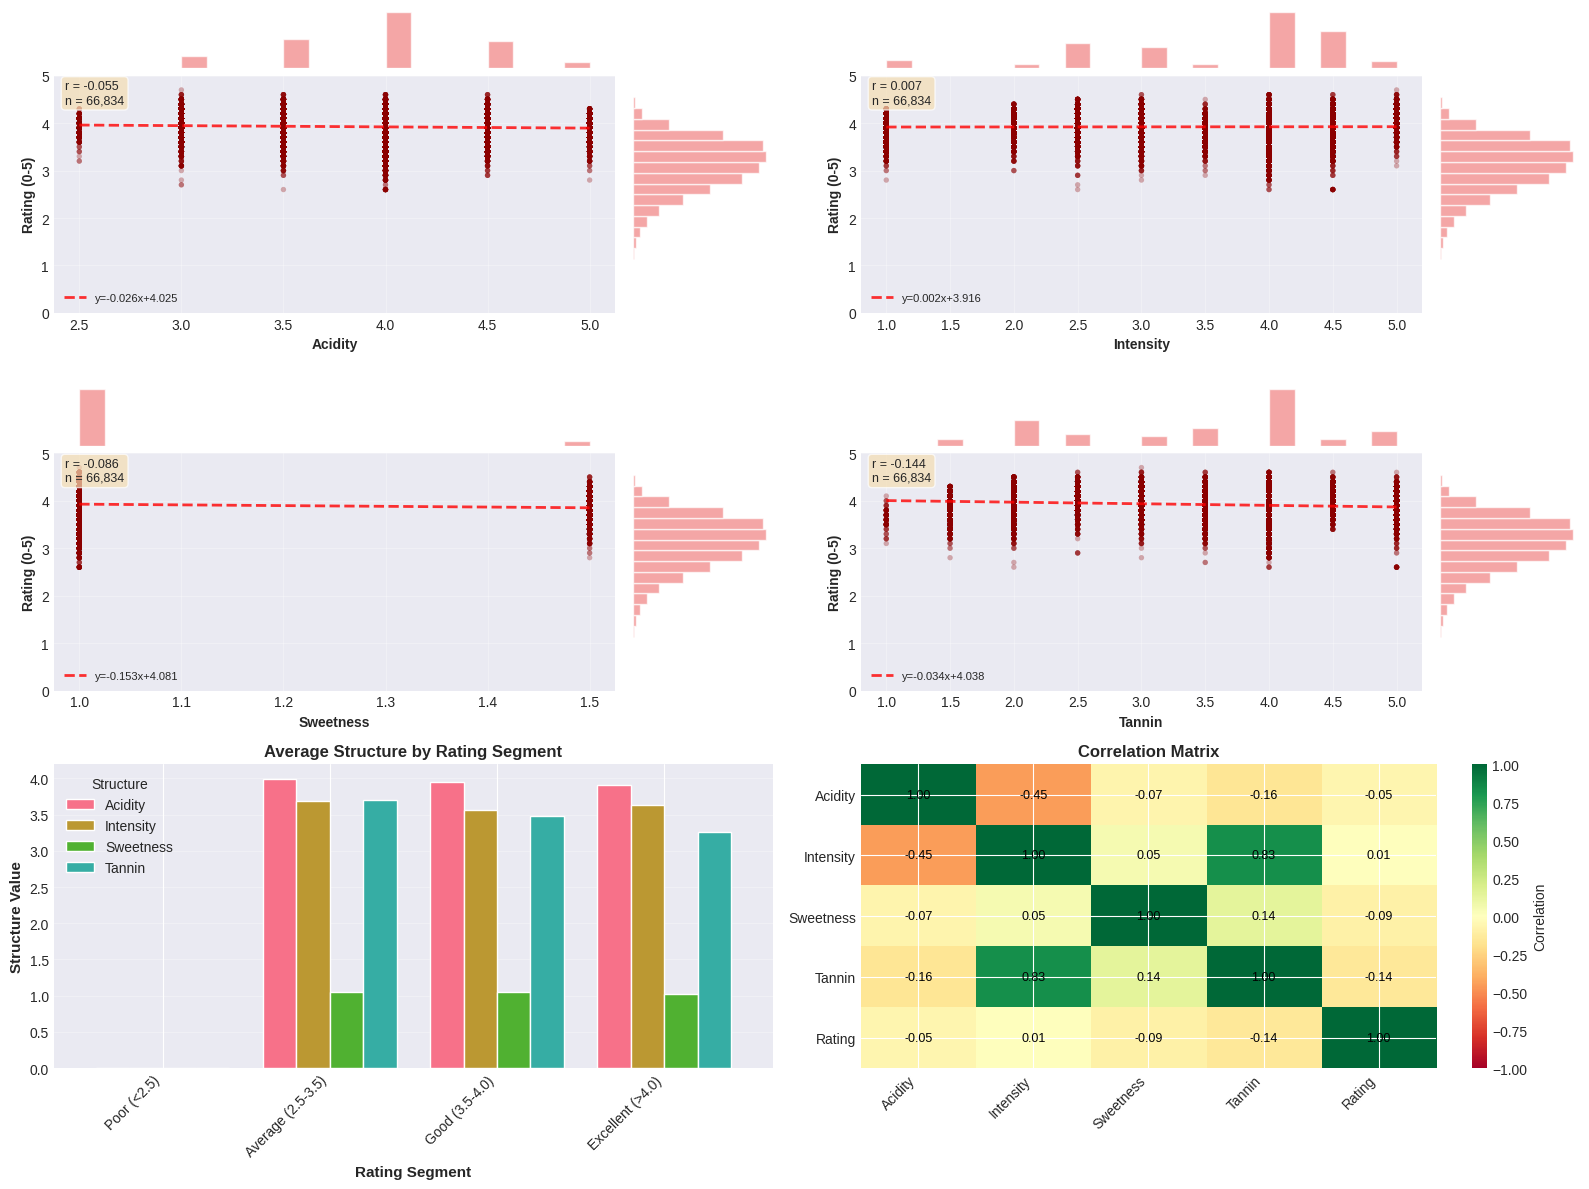


COMPREHENSIVE INSIGHTS:

   1️⃣ Univariate Analysis:
      ✓ Strongest correlation: Tannin (r=-0.144)
      → Very weak individual correlations

   2️⃣ Multivariate Analysis:
      ✓ Combined R²: 0.0774
      → Very limited explanatory power (7.7%)
      ✓ Most influential: Tannin (-0.125 pts/std.dev)

   3️⃣ Rating Segment Patterns:
      ✓ Acidity increases most from Poor to Excellent
        Poor: nan → Excellent: 3.91 (+nan)

   🎯 CONCLUSION:
      ❌ Structure characteristics have LIMITED direct influence on rating
         Other factors (appellation, vintage, variety) dominate ratings
         Structure may matter more within specific wine categories


In [9]:
# ### Q6: Les caractéristiques structurelles influencent-elles la note ?
print("\n🔍 Q6: Les caractéristiques structurelles influencent-elles la note ?")
print("-" * 80)

# Check if structure columns exist
structure_features = ['structure_acidity', 'structure_intensity',
                      'structure_sweetness', 'structure_tannin']

available_features = [col for col in structure_features if col in df.columns]

if not available_features:
    print(" Structure features not available in dataset. Skipping Q6.")
else:
    print(f"Available structure features: {', '.join(available_features)}")

    # Filter valid data (ratings between 0-5, structure values != -1)
    df_q6 = df[(df['vintage_rating'] >= 0) & (df['vintage_rating'] <= 5)& (df['price_availability'] <= 100)].copy()

    for col in available_features:
        df_q6 = df_q6[df_q6[col] != -1]

    print(f"Valid data points: {len(df_q6):,} wines")
    print(f"Rating range: {df_q6['vintage_rating'].min():.2f} - {df_q6['vintage_rating'].max():.2f}")
    print(f"Average rating: {df_q6['vintage_rating'].mean():.2f} ± {df_q6['vintage_rating'].std():.2f}")

    # === 1. UNIVARIATE CORRELATIONS ===
    print(f"\nPearson Correlations with Rating:")
    correlations = {}
    for feature in available_features:
        corr_pearson = df_q6[feature].corr(df_q6['vintage_rating'], method='pearson')
        corr_spearman = df_q6[feature].corr(df_q6['vintage_rating'], method='spearman')
        correlations[feature] = corr_pearson
        print(f"   {feature:25s}: Pearson={corr_pearson:6.3f} | Spearman={corr_spearman:6.3f}")

    # === 2. RATING SEGMENTATION ANALYSIS ===
    print(f"\nRating Segmentation Analysis:")

    # Define rating segments (0-5 scale)
    df_q6['rating_segment'] = pd.cut(df_q6['vintage_rating'],
                                     bins=[0, 2.5, 3.5, 4.0, 5.0],
                                     labels=['Poor (<2.5)', 'Average (2.5-3.5)',
                                             'Good (3.5-4.0)', 'Excellent (>4.0)'])

    # Analyze structure by segment
    segment_stats = df_q6.groupby('rating_segment')[available_features].agg(['mean', 'std', 'count'])

    for feature in available_features:
        print(f"\n   {feature.replace('structure_', '').title()}:")
        for segment in ['Poor (<2.5)', 'Average (2.5-3.5)', 'Good (3.5-4.0)', 'Excellent (>4.0)']:
            if segment in segment_stats.index:
                mean_val = segment_stats.loc[segment, (feature, 'mean')]
                std_val = segment_stats.loc[segment, (feature, 'std')]
                count_val = int(segment_stats.loc[segment, (feature, 'count')])
                print(f"      {segment:20s}: {mean_val:.2f} ± {std_val:.2f} (n={count_val})")

    # === 3. MULTIVARIATE REGRESSION (LINEAR - NO LOG TRANSFORM) ===
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import StandardScaler

    print(f"\nMultiple Linear Regression:")

    X = df_q6[available_features].values
    y = df_q6['vintage_rating'].values  # NO LOG TRANSFORMATION - ratings are 0-5

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit model
    model = LinearRegression()
    model.fit(X_scaled, y)

    # R² score
    r2_score = model.score(X_scaled, y)
    print(f"   R² Score: {r2_score:.4f}")
    print(f"   → Structure features explain {r2_score * 100:.2f}% of rating variance")

    # Feature importance (standardized coefficients)
    print(f"\n   Standardized Coefficients (rating points per std.dev):")
    feature_importance = sorted(zip(available_features, model.coef_),
                                key=lambda x: abs(x[1]), reverse=True)
    for feature, coef in feature_importance:
        print(f"      {feature:25s}: {coef:+7.4f} pts/std.dev")

    print(f"\n   Practical Interpretation:")
    print(f"      • Positive coef → structure increases rating")
    print(f"      • Negative coef → structure decreases rating")
    print(f"      • Coefficient = change in rating (0-5) per 1 std.dev increase")



import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

n_features = len(available_features)
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 2, figure=fig)

for idx, feature in enumerate(available_features):
    row, col = divmod(idx, 2)
    inner_gs = gs[row, col].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                                        wspace=0.05, hspace=0.05)

    ax_histx = fig.add_subplot(inner_gs[0, 0])
    ax_histy = fig.add_subplot(inner_gs[1, 1])
    ax_joint = fig.add_subplot(inner_gs[1, 0])

    x = df_q6[feature]
    y = df_q6['vintage_rating']

    # Scatter
    ax_joint.scatter(x, y, alpha=0.3, s=15, color='darkred', edgecolors='none')

    # Regression line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax_joint.plot(x_line, p(x_line), "r--", lw=2, alpha=0.8,
                  label=f'y={z[0]:.3f}x+{z[1]:.3f}')
    ax_joint.legend(fontsize=8)

    # Labels and grid
    ax_joint.set_xlabel(feature.replace('structure_', '').title(), fontsize=10, fontweight='bold')
    ax_joint.set_ylabel('Rating (0-5)', fontsize=10, fontweight='bold')
    ax_joint.set_ylim(0, 5)
    ax_joint.grid(alpha=0.3)

    # Correlation text
    corr = x.corr(y)
    stats_text = f'r = {corr:.3f}\nn = {len(df_q6):,}'
    ax_joint.text(0.02, 0.98, stats_text, transform=ax_joint.transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # Histograms
    ax_histx.hist(x, bins=20, color='lightcoral', alpha=0.7)
    ax_histy.hist(y, bins=20, color='lightcoral', alpha=0.7, orientation='horizontal')

    # Clean hist axes
    ax_histx.axis('off')
    ax_histy.axis('off')

# ---- Boxplots & Correlation Heatmap stay as before ----
if len(available_features) >= 2:
    ax = fig.add_subplot(gs[2, 0])
    segment_means = df_q6.groupby('rating_segment')[available_features].mean()
    segment_means.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Rating Segment', fontsize=11, fontweight='bold')
    ax.set_ylabel('Structure Value', fontsize=11, fontweight='bold')
    ax.set_title('Average Structure by Rating Segment', fontsize=12, fontweight='bold')
    ax.legend(title='Structure', labels=[f.replace('structure_', '').title() for f in available_features])
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax = fig.add_subplot(gs[2, 1])
    df_q6_corr = df_q6[available_features + ['vintage_rating']].copy()
    corr_matrix = df_q6_corr.corr()
    im = ax.imshow(corr_matrix, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels([c.replace('structure_', '').replace('vintage_rating', 'Rating').title()
                        for c in corr_matrix.columns], rotation=45, ha='right')
    ax.set_yticklabels([c.replace('structure_', '').replace('vintage_rating', 'Rating').title()
                        for c in corr_matrix.columns])
    ax.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha="center", va="center", color="black", fontsize=9)
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    #plt.savefig('./results/plots/charach_vs_rating.png', dpi=300, bbox_inches='tight')

    plt.show()

    # === 5. COMPREHENSIVE INSIGHTS ===
    print(f"\nCOMPREHENSIVE INSIGHTS:")

    # Strongest correlation
    strongest_feature = max(correlations, key=lambda k: abs(correlations[k]))
    strongest_corr = correlations[strongest_feature]

    print(f"\n   1️⃣ Univariate Analysis:")
    print(f"      ✓ Strongest correlation: {strongest_feature.replace('structure_', '').title()} (r={strongest_corr:.3f})")

    if abs(strongest_corr) > 0.3:
        direction = "increases" if strongest_corr > 0 else "decreases"
        print(f"      → Rating {direction} with {strongest_feature.replace('structure_', '').lower()}")
        print(f"      → This is a MODERATE correlation")
    elif abs(strongest_corr) > 0.15:
        direction = "increases" if strongest_corr > 0 else "decreases"
        print(f"      → Rating {direction} weakly with {strongest_feature.replace('structure_', '').lower()}")
        print(f"      → Weak but noticeable relationship")
    else:
        print(f"      → Very weak individual correlations")

    print(f"\n   2️⃣ Multivariate Analysis:")
    print(f"      ✓ Combined R²: {r2_score:.4f}")
    if r2_score > 0.2:
        print(f"      → Structure features explain {r2_score * 100:.1f}% of rating variance")
        print(f"      → This is MEANINGFUL explanatory power")
    elif r2_score > 0.1:
        print(f"      → Combined, they have MODEST explanatory power ({r2_score * 100:.1f}%)")
    else:
        print(f"      → Very limited explanatory power ({r2_score * 100:.1f}%)")

    top_feature, top_coef = feature_importance[0]
    print(f"      ✓ Most influential: {top_feature.replace('structure_', '').title()} ({top_coef:+.3f} pts/std.dev)")

    print(f"\n   3️⃣ Rating Segment Patterns:")
    # Find features that increase most with rating
    poor_means = df_q6[df_q6['rating_segment'] == 'Poor (<2.5)'][available_features].mean()
    excellent_means = df_q6[df_q6['rating_segment'] == 'Excellent (>4.0)'][available_features].mean()

    increases = {}
    for feature in available_features:
        if feature in poor_means.index and feature in excellent_means.index:
            increase = excellent_means[feature] - poor_means[feature]
            increases[feature] = increase

    if increases:
        max_increase_feature = max(increases, key=increases.get)
        max_increase = increases[max_increase_feature]
        print(f"      ✓ {max_increase_feature.replace('structure_', '').title()} increases most from Poor to Excellent")
        print(f"        Poor: {poor_means[max_increase_feature]:.2f} → Excellent: {excellent_means[max_increase_feature]:.2f} (+{max_increase:.2f})")

    print(f"\n   🎯 CONCLUSION:")
    if r2_score > 0.2 or abs(strongest_corr) > 0.3:
        print(f"       Structure characteristics DO meaningfully influence rating")
        print(f"         Particularly {strongest_feature.replace('structure_', '').lower()} (r={strongest_corr:.3f})")
        print(f"         Combined R²={r2_score:.3f} shows moderate predictive power")
    elif r2_score > 0.1 or abs(strongest_corr) > 0.15:
        print(f"       Structure characteristics have MODEST influence on rating")
        print(f"         Some signal present, but other factors likely more important")
    else:
        print(f"      ❌ Structure characteristics have LIMITED direct influence on rating")
        print(f"         Other factors (appellation, vintage, variety) dominate ratings")
        print(f"         Structure may matter more within specific wine categories")

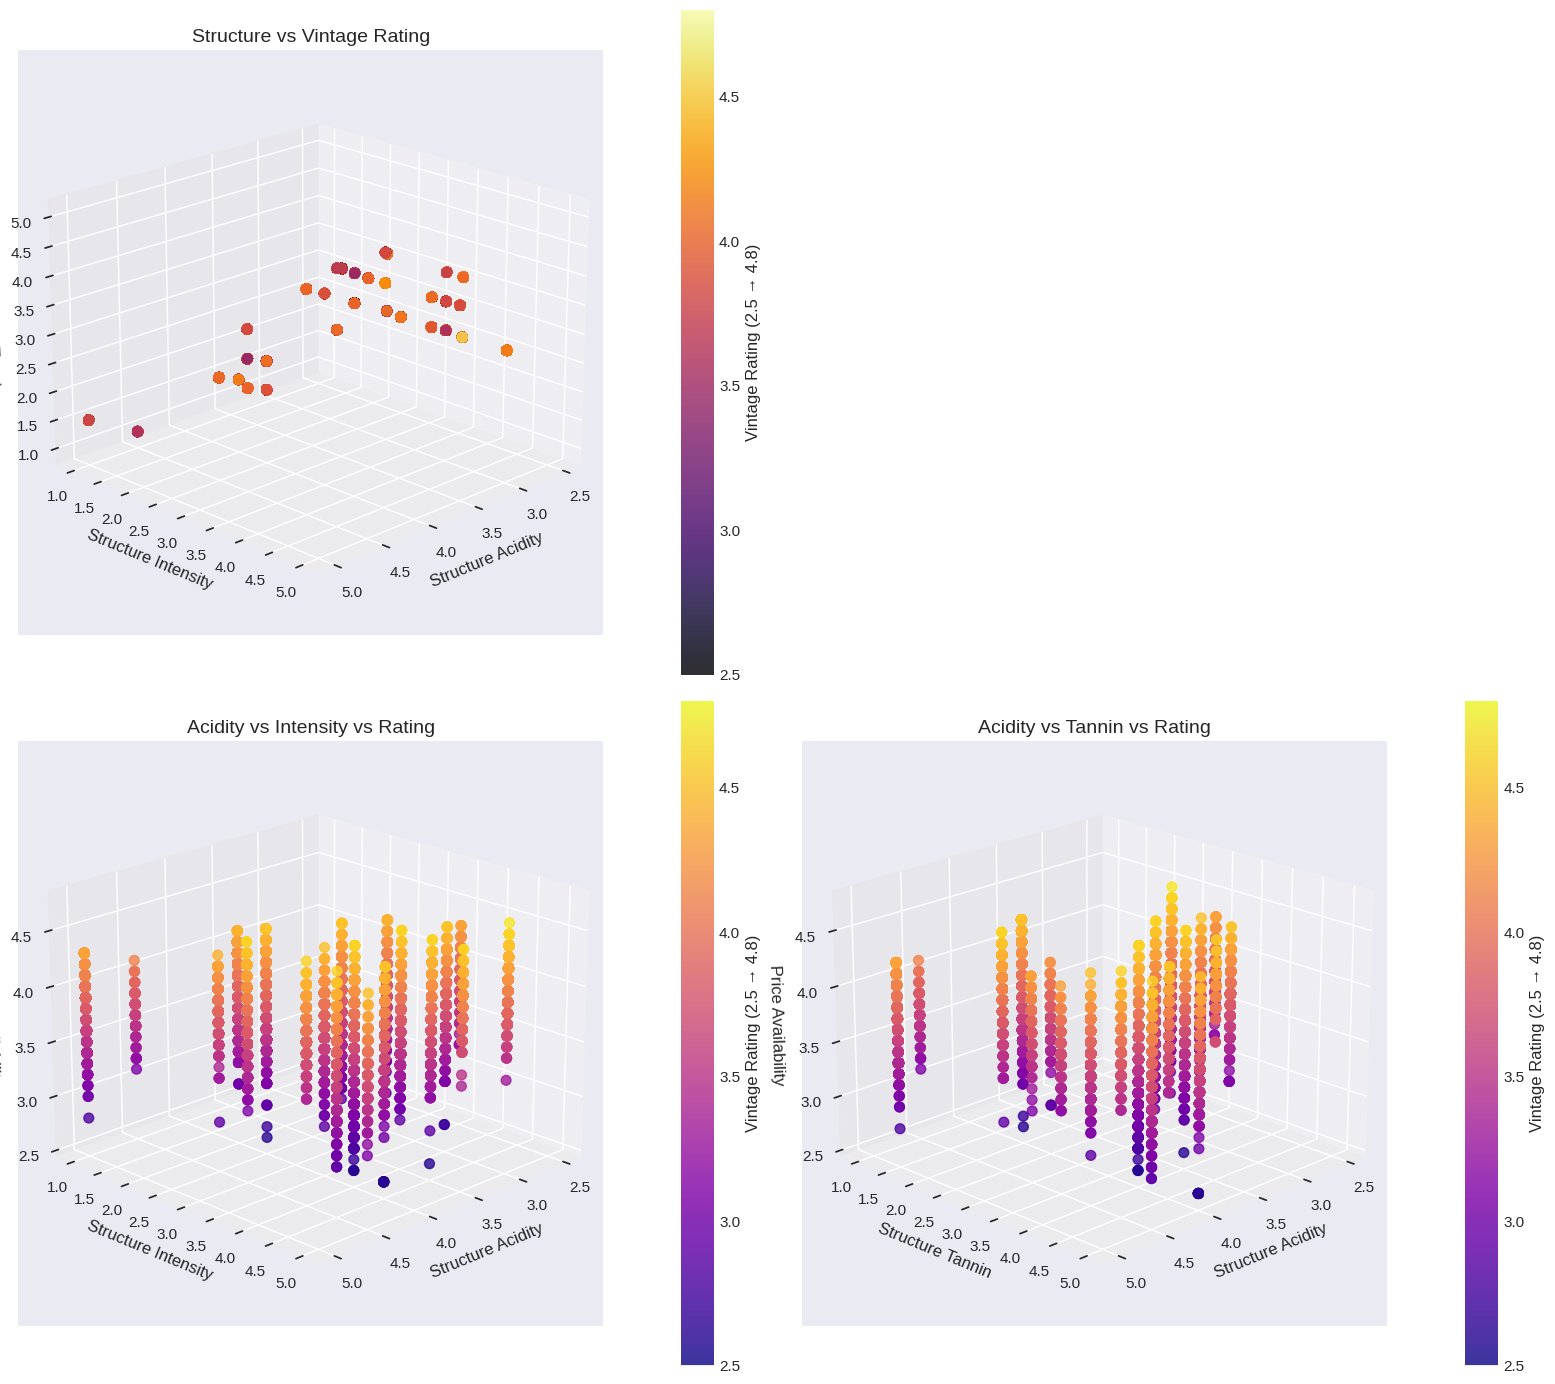

In [160]:
# there is 3 clusters, based on the fact that tannin and intensity are strongly correlated i splitted them both into 2 3D graph
# tp better observe the rating distribution  which is hard to see on the first 4D graph
# we observe the 3 same cluster for both ( confirming the correlation), but the distribution of rating is evenly distributed this no real info to win or feature engineer from those 3 clusters (damn) !

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Remove rows with missing values in all relevant columns
plot_data = df_q6[['structure_acidity', 'structure_intensity', 'structure_tannin', 'vintage_rating', 'price_availability']].dropna()

# Normalize vintage_rating for coloring
norm = plt.Normalize(vmin=2.5, vmax=4.8)

# Create 3D figure with 2 rows x 2 columns
fig = plt.figure(figsize=(16, 14))

# Top-left: Structure vs Vintage Rating
ax1 = fig.add_subplot(221, projection='3d')
p1 = ax1.scatter(
    plot_data['structure_acidity'],
    plot_data['structure_intensity'],
    plot_data['structure_tannin'],
    c=plot_data['vintage_rating'],
    cmap='inferno',
    norm=norm,
    s=50,
    alpha=0.8
)
ax1.set_title('Structure vs Vintage Rating', fontsize=14)
ax1.set_xlabel('Structure Acidity')
ax1.set_ylabel('Structure Intensity')
ax1.set_zlabel('Structure Tannin')
ax1.view_init(elev=20, azim=45)
cbar1 = fig.colorbar(p1, ax=ax1, pad=0.1)
cbar1.set_label('Vintage Rating (2.5 → 4.8)')

# Bottom-left: Acidity vs Intensity vs Price
ax2 = fig.add_subplot(223, projection='3d')
p2 = ax2.scatter(
    plot_data['structure_acidity'],
    plot_data['structure_intensity'],
    plot_data['vintage_rating'],
    c=plot_data['vintage_rating'],
    cmap='plasma',
    norm=norm,
    s=50,
    alpha=0.8
)
ax2.set_title('Acidity vs Intensity vs Rating', fontsize=14)
ax2.set_xlabel('Structure Acidity')
ax2.set_ylabel('Structure Intensity')
ax2.set_zlabel('Price Availability')
ax2.view_init(elev=20, azim=45)
cbar2 = fig.colorbar(p2, ax=ax2, pad=0.1)
cbar2.set_label('Vintage Rating (2.5 → 4.8)')

# Bottom-right: Acidity vs Tannin vs Price
ax3 = fig.add_subplot(224, projection='3d')
p3 = ax3.scatter(
    plot_data['structure_acidity'],
    plot_data['structure_tannin'],
    plot_data['vintage_rating'],
    c=plot_data['vintage_rating'],
    cmap='plasma',
    norm=norm,
    s=50,
    alpha=0.8
)
ax3.set_title('Acidity vs Tannin vs Rating', fontsize=14)
ax3.set_xlabel('Structure Acidity')
ax3.set_ylabel('Structure Tannin')
ax3.set_zlabel('Price Availability')
ax3.view_init(elev=20, azim=45)
cbar3 = fig.colorbar(p3, ax=ax3, pad=0.1)
cbar3.set_label('Vintage Rating (2.5 → 4.8)')

plt.tight_layout()
plt.show()


### 3.2 Categorical datas
### 3.2.1 region                   object

#### Key Findings

**Region is a strong predictor of wine rating**, explaining **39.1% of rating variance** (R² = 0.3905) across 66,834 wines with valid ratings. This is excellent for a single categorical feature and establishes region as likely one of the most important predictors in the dataset. ANOVA confirms highly significant rating differences between regions (F = 66.76, p < 0.001).

However, **high cardinality presents a challenge**: 746 unique regions, with 422 regions having ≥10 wines. Using region alone yields an expected RMSE of ~0.19 points, leaving 60.9% of variance unexplained—indicating other features (variety, vintage, producer) are still necessary.

#### Visual Analysis

**Graph 1 (Distribution of Region Sizes)**: Shows extreme imbalance with ~324 regions having fewer than 10 wines (left peak) while only ~127 regions exceed 100 wines. This long-tail distribution highlights the high cardinality problem—many rare regions risk overfitting.

**Graph 2 (Cumulative Coverage)**: Demonstrates the Pareto principle—just 100 regions (13.4% of total) cover 80% of all wines, while 177 regions cover 90%. The remaining 500+ regions represent only 10% of the dataset, justifying a filtering strategy.

**Graph 3 (Rating Distribution by Top 15 Regions)**: Boxplots reveal clear visual separation between regions (e.g., Bordeaux vs Pomerol vs Margaux), with red diamonds showing mean ratings ranging from ~3.6 to 4.2. This separation validates region's strong predictive power, though overlapping boxes indicate substantial intra-region variance.

**Graph 4 (Region Stability Analysis)**: Scatter plot with bubble size/color representing rating standard deviation. Green bubbles (low std) at high volume identify stable, reliable predictors like St-Emilion-Grand-Cru, Châteauneuf-du-Pape, and Haut-Médoc. Larger/darker bubbles indicate volatile regions with inconsistent ratings—useful signal but noisier for modeling.

#### Encoding Strategy

Given the high cardinality (746 regions) but strong predictive power (R² = 0.39), I will implement **two encoding approaches** and compare performance:

#### Primary Approach: Target Encoding
Transform the 746 categorical regions into 4 numeric features:
- `region_mean_smoothed`: Bayesian-smoothed mean rating = (n × region_mean + k × global_mean) / (n + k) where k=10
- `region_median`: Median rating (robust to outliers)
- `region_count`: Number of wines (confidence indicator, log-transformed)
- `region_std`: Rating variability (stability indicator)

**Advantages**: Captures 100% of regions with only 4 columns, no information loss, works excellently with all planned models (RF, XGBoost, LightGBM, Linear, Ridge/Lasso). Critical implementation requirement: compute encodings only on training folds during cross-validation to prevent data leakage.

#### Alternative Approach: One-Hot Encoding
Keep top 100 regions (80% coverage) with frequency threshold ≥~120 wines, grouping remaining as 'Other'.

**Trade-offs**: 101 columns vs 4, loses 20% of wines to 'Other' category, slower training.

Both approaches will be tested empirically, with target encoding as primary due to its efficiency and universal compatibility with our model suite.


🔍 Q3: Is region a predictive feature for rating, and how to encode it effectively?
Working with 66834 wines with valid ratings
📍 Total unique regions: 746

PART A: PREDICTIVE POWER OF REGION

Variance Analysis:
   Total variance:              0.0567
   Total std deviation:         0.24 points
   Between-region variance:     0.0222
   R² (explained by region):    0.3905 (39.05%)
   Expected RMSE (region only): 0.19 points

Interpretation:
    STRONG predictor - Region explains 39.1% of rating variance
   → This is EXCELLENT for a single categorical feature!
   → But leaves ~0.19 points average error (60.9% unexplained variance)

ANOVA Test:
   F-statistic: 66.76
   p-value: 0.00e+00
   → Regions have SIGNIFICANTLY different ratings

🔍 Sanity Check:
   Manual R² (predict region mean): 0.3905
   Calculated R² (ANOVA):           0.3905
   Match:  Valid

PART B: CARDINALITY PROBLEM

Region Distribution:
   Total regions: 746
   Regions with >= 100 wines: 127
   Regions with >= 50 wines:  1

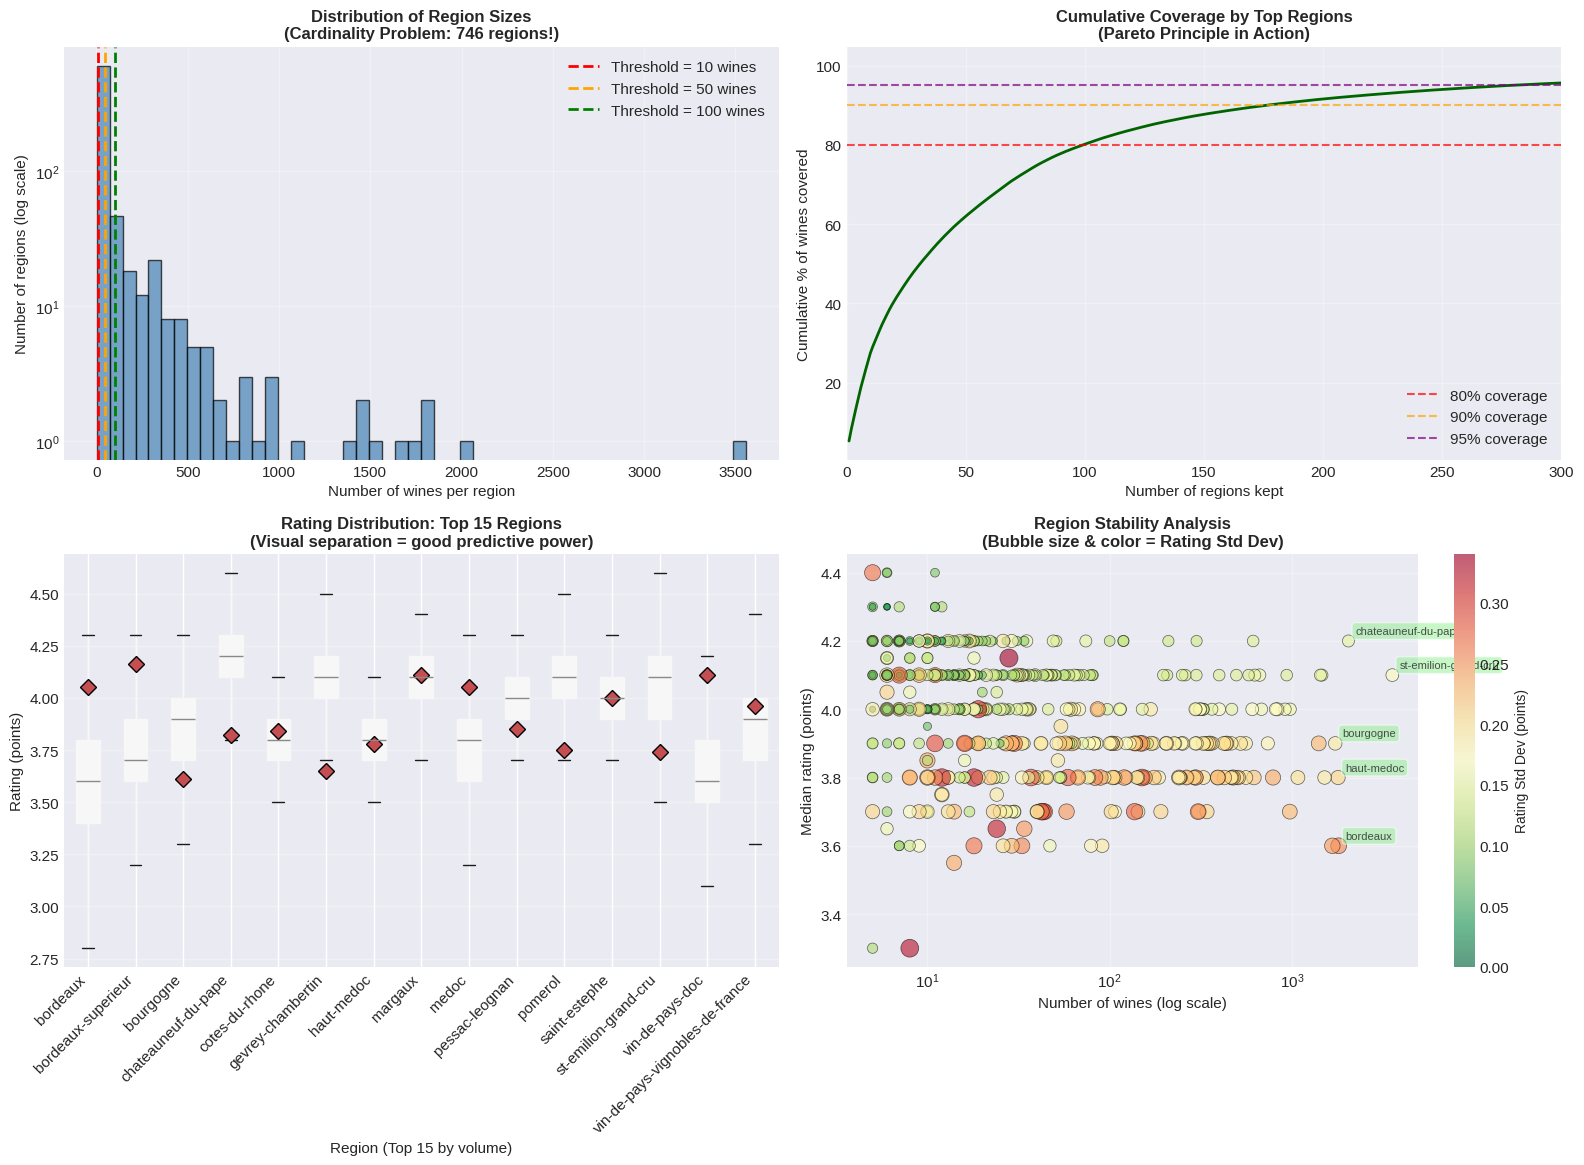

In [162]:
# ### Q3: Is region a predictive feature for rating, and how to encode it effectively to avoid overfitting due to high cardinality?
print("\n🔍 Q3: Is region a predictive feature for rating, and how to encode it effectively?")
print("=" * 80)

# Filter data to valid ratings only
df_q3 = df[(df['price_availability'] < 100)].copy()
print(f"Working with {len(df_q3)} wines with valid ratings")
print(f"📍 Total unique regions: {df_q3['region'].nunique()}")

# ============================================================================
# PART A: Does region predict rating? (Variance analysis)
# ============================================================================
print("\n" + "=" * 80)
print("PART A: PREDICTIVE POWER OF REGION")
print("=" * 80)

# Calculate variance components
total_variance = df_q3['vintage_rating'].var()
overall_mean = df_q3['vintage_rating'].mean()
total_std = np.sqrt(total_variance)

# Between-group variance
region_means = df_q3.groupby('region')['vintage_rating'].agg(['mean', 'count'])
between_var = ((region_means['mean'] - overall_mean) ** 2 * region_means['count']).sum() / len(df_q3)

# R² (variance explained by region)
r_squared = between_var / total_variance

# Calculate expected RMSE
residual_variance = total_variance * (1 - r_squared)
expected_rmse = np.sqrt(residual_variance)

print(f"\nVariance Analysis:")
print(f"   Total variance:              {total_variance:.4f}")
print(f"   Total std deviation:         {total_std:.2f} points")
print(f"   Between-region variance:     {between_var:.4f}")
print(f"   R² (explained by region):    {r_squared:.4f} ({r_squared * 100:.2f}%)")
print(f"   Expected RMSE (region only): {expected_rmse:.2f} points")

print(f"\nInterpretation:")
print(f"    STRONG predictor - Region explains {r_squared * 100:.1f}% of rating variance")
print(f"   → This is EXCELLENT for a single categorical feature!")
print(f"   → But leaves ~{expected_rmse:.2f} points average error ({(1-r_squared)*100:.1f}% unexplained variance)")

# ANOVA F-test
from scipy import stats

region_groups = [group['vintage_rating'].values for name, group in df_q3.groupby('region') if len(group) >= 3]
f_stat, p_value = stats.f_oneway(*region_groups)
print(f"\nANOVA Test:")
print(f"   F-statistic: {f_stat:.2f}")
print(f"   p-value: {p_value:.2e}")
print(f"   → Regions have {'SIGNIFICANTLY' if p_value < 0.001 else 'NOT significantly'} different ratings")

# Sanity check: Manual R² calculation
df_test = df_q3.copy()
region_stats_temp = df_q3.groupby('region')['vintage_rating'].mean()
df_test['predicted_naive'] = df_test['region'].map(region_stats_temp)
from sklearn.metrics import r2_score

r2_manual = r2_score(df_test['vintage_rating'], df_test['predicted_naive'])
print(f"\n🔍 Sanity Check:")
print(f"   Manual R² (predict region mean): {r2_manual:.4f}")
print(f"   Calculated R² (ANOVA):           {r_squared:.4f}")
print(f"   Match: {' Valid' if abs(r2_manual - r_squared) < 0.01 else '❌ Error in calculation'}")

# ============================================================================
# PART B: Cardinality problem - How many regions to keep?
# ============================================================================
print("\n" + "=" * 80)
print("PART B: CARDINALITY PROBLEM")
print("=" * 80)

# Region statistics
region_stats = df_q3.groupby('region').agg({
    'vintage_rating': ['count', 'mean', 'median', 'std']
}).round(2)
region_stats.columns = ['count', 'mean_rating', 'median_rating', 'std_rating']
region_stats = region_stats.sort_values('count', ascending=False)

print(f"\nRegion Distribution:")
print(f"   Total regions: {len(region_stats)}")
print(f"   Regions with >= 100 wines: {(region_stats['count'] >= 100).sum()}")
print(f"   Regions with >= 50 wines:  {(region_stats['count'] >= 50).sum()}")
print(f"   Regions with >= 20 wines:  {(region_stats['count'] >= 20).sum()}")
print(f"   Regions with >= 10 wines:  {(region_stats['count'] >= 10).sum()}")
print(f"   Regions with 1-9 wines:    {(region_stats['count'] < 10).sum()}")

print(f"\n High Cardinality Challenge:")
print(f"   Even with threshold >= 10: still {(region_stats['count'] >= 10).sum()} regions!")
print(f"   One-hot encoding would create {(region_stats['count'] >= 10).sum()} columns → NOT recommended")

# Visualize cardinality distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A1: Histogram of wines per region (log scale)
ax = axes[0, 0]
counts = region_stats['count'].values
ax.hist(counts, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(10, color='red', linestyle='--', linewidth=2, label='Threshold = 10 wines')
ax.axvline(50, color='orange', linestyle='--', linewidth=2, label='Threshold = 50 wines')
ax.axvline(100, color='green', linestyle='--', linewidth=2, label='Threshold = 100 wines')
ax.set_xlabel('Number of wines per region', fontsize=11)
ax.set_ylabel('Number of regions (log scale)', fontsize=11)
ax.set_title(f'Distribution of Region Sizes\n(Cardinality Problem: {len(region_stats)} regions!)',
             fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# A2: Cumulative coverage
ax = axes[0, 1]
region_stats_sorted = region_stats.sort_values('count', ascending=False)
cumsum_wines = region_stats_sorted['count'].cumsum()
cumsum_pct = (cumsum_wines / len(df_q3)) * 100
ax.plot(range(1, len(cumsum_pct) + 1), cumsum_pct, linewidth=2, color='darkgreen')
ax.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% coverage')
ax.axhline(90, color='orange', linestyle='--', alpha=0.7, label='90% coverage')
ax.axhline(95, color='purple', linestyle='--', alpha=0.7, label='95% coverage')
ax.set_xlabel('Number of regions kept', fontsize=11)
ax.set_ylabel('Cumulative % of wines covered', fontsize=11)
ax.set_title('Cumulative Coverage by Top Regions\n(Pareto Principle in Action)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 300)
ax.legend()
ax.grid(True, alpha=0.3)

# Find how many regions needed for different coverages
n_regions_80 = (cumsum_pct >= 80).argmax() + 1
n_regions_90 = (cumsum_pct >= 90).argmax() + 1
n_regions_95 = (cumsum_pct >= 95).argmax() + 1
print(f"\nCoverage Analysis (Pareto Principle):")
print(f"   Top {n_regions_80} regions cover 80% of wines ({n_regions_80 / len(region_stats) * 100:.1f}% of regions)")
print(f"   Top {n_regions_90} regions cover 90% of wines ({n_regions_90 / len(region_stats) * 100:.1f}% of regions)")
print(f"   Top {n_regions_95} regions cover 95% of wines ({n_regions_95 / len(region_stats) * 100:.1f}% of regions)")

# B1: Boxplot of top 15 regions by count
ax = axes[1, 0]
top_15_regions = region_stats.head(15).index
df_top15 = df_q3[df_q3['region'].isin(top_15_regions)]
df_top15.boxplot(column='vintage_rating', by='region', ax=ax,
                 patch_artist=True, showfliers=False)
ax.set_xlabel('Region (Top 15 by volume)', fontsize=11)
ax.set_ylabel('Rating (points)', fontsize=11)
ax.set_title('Rating Distribution: Top 15 Regions\n(Visual separation = good predictive power)',
             fontsize=12, fontweight='bold')
ax.get_figure().suptitle('')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add mean ratings as red diamonds
for i, region in enumerate(top_15_regions, 1):
    mean_val = region_stats.loc[region, 'mean_rating']
    ax.plot(i, mean_val, 'rD', markersize=8, markeredgecolor='black', markeredgewidth=1)

# B2: Scatter plot - Stability analysis
ax = axes[1, 1]
region_stats_filtered = region_stats[region_stats['count'] >= 5]
scatter = ax.scatter(region_stats_filtered['count'],
                     region_stats_filtered['median_rating'],
                     s=region_stats_filtered['std_rating'] * 500,  # Scale bubble size appropriately
                     c=region_stats_filtered['std_rating'],
                     cmap='RdYlGn_r',
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)
ax.set_xlabel('Number of wines (log scale)', fontsize=11)
ax.set_ylabel('Median rating (points)', fontsize=11)
ax.set_title('Region Stability Analysis\n(Bubble size & color = Rating Std Dev)',
             fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rating Std Dev (points)', fontsize=10)

# Highlight best regions for ML: high volume + low std = reliable predictors
stable_regions = region_stats_filtered[
    (region_stats_filtered['count'] >= 100) &
    (region_stats_filtered['std_rating'] < 0.90)  # Low variability for 0-5 scale
]
print(f"\n🎯 Most Reliable Regions for ML (volume >= 100, std < 0.30): {len(stable_regions)}")
if len(stable_regions) > 0:
    for idx, row in stable_regions.head(5).iterrows():
        ax.annotate(idx[:20],
                    xy=(row['count'], row['median_rating']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))
    print(stable_regions[['count', 'mean_rating', 'median_rating', 'std_rating']].head())

plt.tight_layout()
plt.show()

### 3.2.2 grapes                   object
Wine grape varieties show moderate correlation with quality ratings (R²=0.109), but this effect is completely overshadowed by regional factors, which alone explain 35.2% of rating variance.

The initial observation that blends score slightly higher (+0.10 points)  is not really significant

After controlling for region and grape variety, the blend variable contributes no additional explanatory power. For predictive modeling, region emerges as the dominant feature, with grape variety information being largely redundant due to AOC regulations linking varieties to terroir.


🔍 Q4: ANALYSE SIMPLIFIÉE - Assemblages vs Mono-cépages
📊 Analyse sur dataset Q95 (note < pts385)
--------------------------------------------------------------------------------

📊 ANALYSE 1: APPROCHE NAÏVE (sans contrôle)

   → Différence: +0.10 pts (1.03x)

🧪 Test Mann-Whitney U:
   p-value = 0.000000
   → Différence significative (α=0.001)

💡 Conclusion naïve:
   Les mono-cépages et assemblages ont des notes similaires

📊 ANALYSE 2: CONTRÔLE PAR CÉPAGE PRINCIPAL

⚙️  Régression Ridge avec cépage principal...
   R² = 0.0316 (±0.0408)
   → Le cépage principal explique 3.2% de la variance des notes

🏆 Top 10 cépages (par note médiane):
    1. pinot-noir               :   4.00 pts (n=16,593)
    2. cabernet-franc           :   3.90 pts (n=2,140)
    3. grenache-noir            :   3.90 pts (n=291)
    4. cabernet-sauvignon       :   3.90 pts (n=21,118)
    5. shiraz-syrah             :   3.90 pts (n=18,764)
    6. Unknown                  :   3.80 pts (n=4,109)
    7. gamay            

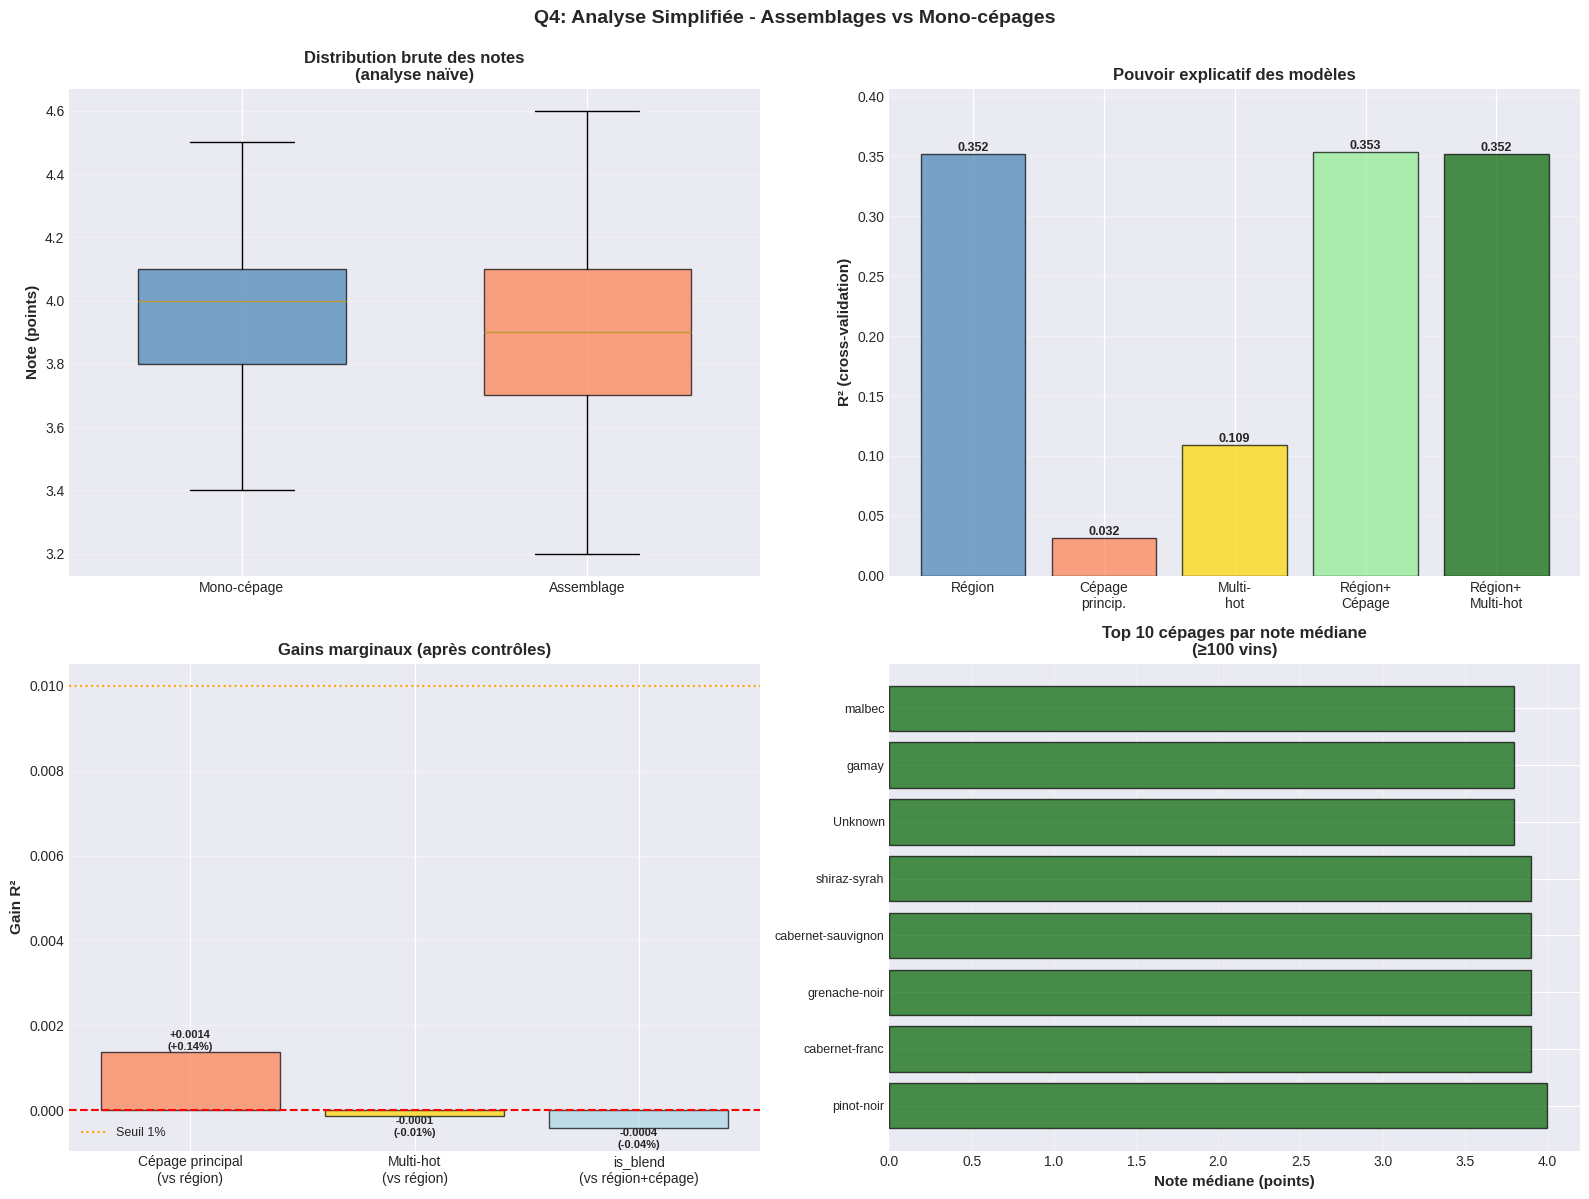


🎯 CONCLUSIONS FINALES

1️⃣ Question initiale: "Les assemblages sont-ils mieux notés?"
   Réponse naïve: Oui
   Différence observée: +0.10 pts

2️⃣ Après contrôle (région + cépage):
   → Effet ARTEFACT / CONFOUNDING
   → La différence s'explique par la région et le type de cépage
   → is_blend n'a PAS d'effet propre significatif

3️⃣ Hiérarchie des effets:
   1. Région:          R² = 0.352 (35.2%)
   2. + Cépage:        R² = 0.353 (gain: +0.1%)
   3. + Multi-hot:     R² = 0.352 (gain: -0.0%)

4️⃣ Recommandation features pour modèle:
   ✅ GARDER: région seule
      → Cépages redondants avec région (AOC)

   ❌ SUPPRIMER: is_blend (gain < 0.5%)

✅ ANALYSE TERMINÉE


In [13]:

print("\n🔍 Q4: ANALYSE SIMPLIFIÉE - Assemblages vs Mono-cépages")
print("=" * 80)
print("📊 Analyse sur dataset Q95 (note < pts385)")
print("=" * 80)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import ast







def extract_all_grapes(grapes_str):
    """
    Extrait TOUS les cépages d'une entrée (mono-cépage ou assemblage)
    Retourne une liste de cépages (nettoyés)
    """
    # Gérer les valeurs manquantes
    if pd.isna(grapes_str) or grapes_str == '' or str(grapes_str).strip() in ['nan', 'None', 'Unknown']:
        return []

    try:
        # Si c'est déjà une liste, on l'utilise directement
        if isinstance(grapes_str, list):
            grapes_list = grapes_str
        else:
            # Méthode robuste : remplacer () par [] pour JSON
            grapes_str_clean = str(grapes_str).replace("'", '"').replace('(', '[').replace(')', ']')
            grapes_list = json.loads(grapes_str_clean)

        if isinstance(grapes_list, list):
            cleaned = []
            for grape in grapes_list:
                if isinstance(grape, (list, tuple)) and len(grape) >= 2:
                    # Format: [percentage, name] ou [name, percentage]
                    if isinstance(grape[1], str):
                        grape_name = grape[1]
                    elif isinstance(grape[0], str):
                        grape_name = grape[0]
                    else:
                        continue
                else:
                    grape_name = grape

                cleaned.append(str(grape_name).strip())
            return cleaned
        return []
    except Exception as e:
        # Afficher seulement les vraies erreurs (pas les Unknown)
        if str(grapes_str) != 'Unknown':
            print(f"⚠️ Erreur inattendue sur: {str(grapes_str)[:100]}... | {e}")
        return []

def is_blend(grapes_list):
    """Check if wine is a blend (>1 grape variety)"""
    return len(grapes_list) > 1

import json

# Application
print("-" * 80)
df_q4 = df[(df['price_availability'] < 100)].copy()


df_q4['grapes_list'] = df_q4['grapes'].apply(extract_all_grapes)
df_q4['is_blend'] = df_q4['grapes_list'].apply(is_blend)
df_q4['n_grapes'] = df_q4['grapes_list'].apply(len)
df_q4['primary_grape'] = df_q4['grapes_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# ============================================================================
# ANALYSE 1: APPROCHE NAÏVE (Blend vs Mono, sans contrôle)
# ============================================================================

print("\n" + "=" * 80)
print("📊 ANALYSE 1: APPROCHE NAÏVE (sans contrôle)")
print("=" * 80)

mono_ratings = df_q4[~df_q4['is_blend']]['vintage_rating']
blend_ratings = df_q4[df_q4['is_blend']]['vintage_rating']




diff = mono_ratings.median() - blend_ratings.median()
ratio = mono_ratings.median() / blend_ratings.median()
print(f"\n   → Différence: {diff:+.2f} pts ({ratio:.2f}x)")

# Test statistique
u_stat, p_value = mannwhitneyu(mono_ratings, blend_ratings, alternative='two-sided')
print(f"\n🧪 Test Mann-Whitney U:")
print(f"   p-value = {p_value:.6f}")
print(f"   → Différence {'significative' if p_value < 0.001 else 'non significative'} (α=0.001)")

print(f"\n💡 Conclusion naïve:")
if abs(diff) < 5:
    print(f"   Les mono-cépages et assemblages ont des notes similaires")
elif diff > 0:
    print(f"   Les mono-cépages semblent mieux notés (+{diff:.1f} pts)")
else:
    print(f"   Les assemblages semblent mieux notés (+{abs(diff):.1f} pts)")

# ============================================================================
# ANALYSE 2: CONTRÔLE PAR CÉPAGE PRINCIPAL
# ============================================================================

print("\n" + "=" * 80)
print("📊 ANALYSE 2: CONTRÔLE PAR CÉPAGE PRINCIPAL")
print("=" * 80)

# Target encoding du cépage principal (avec CV)
from sklearn.model_selection import KFold

def target_encode_cv(X_cat, y, n_folds=5, smoothing=10):
    """Target encoding avec validation croisée"""
    X_encoded = np.zeros(len(X_cat))
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    X_series = pd.Series(X_cat)
    y_series = pd.Series(y)
    global_mean = y_series.mean()

    for train_idx, val_idx in kf.split(X_cat):
        train_x = X_series.iloc[train_idx]
        train_y = y_series.iloc[train_idx]

        stats = train_y.groupby(train_x).agg(['mean', 'count'])
        smoothed_means = (
            (stats['count'] * stats['mean'] + smoothing * global_mean) /
            (stats['count'] + smoothing)
        )

        X_encoded[val_idx] = X_series.iloc[val_idx].map(smoothed_means).fillna(global_mean).values

    return X_encoded

y = df_q4['vintage_rating'].values

# Modèle avec cépage principal seul
print("\n⚙️  Régression Ridge avec cépage principal...")
primary_grape_encoded = target_encode_cv(df_q4['primary_grape'].values, y)
X_primary = primary_grape_encoded.reshape(-1, 1)
scores_primary = cross_val_score(Ridge(alpha=10.0), X_primary, y, cv=5, scoring='r2')

print(f"   R² = {scores_primary.mean():.4f} (±{scores_primary.std():.4f})")
print(f"   → Le cépage principal explique {scores_primary.mean() * 100:.1f}% de la variance des notes")

# Top 10 cépages par note médiane
print(f"\n🏆 Top 10 cépages (par note médiane):")
grape_stats = df_q4.groupby('primary_grape').agg({
    'vintage_rating': ['median', 'mean', 'count']
}).round(2)
grape_stats.columns = ['median', 'mean', 'count']
grape_stats = grape_stats[grape_stats['count'] >= 100].sort_values('median', ascending=False)

for idx, (grape, row) in enumerate(grape_stats.head(10).iterrows(), 1):
    print(f"   {idx:2d}. {grape:25s}: {row['median']:6.2f} pts (n={int(row['count']):,})")

# ============================================================================
# ANALYSE 3: ENCODAGE MULTI-HOT (tous les cépages)
# ============================================================================

print("\n" + "=" * 80)
print("📊 ANALYSE 3: ENCODAGE MULTI-HOT (assemblages complets)")
print("=" * 80)

# Construire liste des cépages fréquents (≥100 occurrences)
all_grapes = []
for grapes_list in df_q4['grapes_list']:
    all_grapes.extend(grapes_list)

grape_counts = pd.Series(all_grapes).value_counts()
min_occurrences = 100
top_grapes = grape_counts[grape_counts >= min_occurrences].index.tolist()

print(f"\n✅ Cépages retenus: {len(top_grapes)} (≥{min_occurrences} occurrences)")
print(f"   Top 10: {', '.join(top_grapes[:10])}")

# Créer features binaires
print(f"\n⚙️  Création encodage multi-hot...")
for grape in top_grapes:
    df_q4[f'has_{grape}'] = df_q4['grapes_list'].apply(lambda x: grape in x).astype(int)

X_multihot = df_q4[[f'has_{g}' for g in top_grapes]].values

# Statistiques
active_features = X_multihot.sum(axis=1)
print(f"   • Features actives par vin (moyenne): {active_features.mean():.2f}")
print(f"   • Features actives par vin (médiane): {np.median(active_features):.0f}")

# Modèle multi-hot
print(f"\n⚙️  Régression Ridge avec multi-hot encoding...")
scores_multihot = cross_val_score(Ridge(alpha=10.0), X_multihot, y, cv=5, scoring='r2')

print(f"   R² = {scores_multihot.mean():.4f} (±{scores_multihot.std():.4f})")
print(f"   → L'encodage multi-hot explique {scores_multihot.mean() * 100:.1f}% de la variance")

gain_multihot_vs_primary = scores_multihot.mean() - scores_primary.mean()
print(f"\n📈 Gain vs cépage principal: {gain_multihot_vs_primary:+.4f} ({gain_multihot_vs_primary * 100:+.2f}%)")

if gain_multihot_vs_primary > 0.01:  # 1% gain
    print(f"   → Les combinaisons de cépages apportent de l'information supplémentaire")
else:
    print(f"   → Le cépage principal capture déjà l'essentiel de l'information")

# ============================================================================
# ANALYSE 4: AJOUT DE LA RÉGION (contrôle confondant)
# ============================================================================

print("\n" + "=" * 80)
print("📊 ANALYSE 4: AJOUT RÉGION (contrôle du facteur confondant)")
print("=" * 80)

# Modèle région seule
print("\n⚙️  Modèle 1: Région seule...")
region_encoded = target_encode_cv(df_q4['region'].values, y)
X_region = region_encoded.reshape(-1, 1)
scores_region = cross_val_score(Ridge(alpha=10.0), X_region, y, cv=5, scoring='r2')

print(f"   R² = {scores_region.mean():.4f} (±{scores_region.std():.4f})")

# Modèle région + cépage principal
print("\n⚙️  Modèle 2: Région + Cépage principal...")
X_region_primary = np.column_stack([region_encoded, primary_grape_encoded])
scores_region_primary = cross_val_score(Ridge(alpha=10.0), X_region_primary, y, cv=5, scoring='r2')

print(f"   R² = {scores_region_primary.mean():.4f} (±{scores_region_primary.std():.4f})")

# Modèle région + multi-hot
print("\n⚙️  Modèle 3: Région + Multi-hot...")
X_region_multihot = np.column_stack([region_encoded, X_multihot])
scores_region_multihot = cross_val_score(Ridge(alpha=10.0), X_region_multihot, y, cv=5, scoring='r2')

print(f"   R² = {scores_region_multihot.mean():.4f} (±{scores_region_multihot.std():.4f})")

# Gains marginaux
gain_primary_given_region = scores_region_primary.mean() - scores_region.mean()
gain_multihot_given_region = scores_region_multihot.mean() - scores_region.mean()

print(f"\n📈 Gains marginaux (après contrôle région):")
print(f"   • Cépage principal: {gain_primary_given_region:+.4f} ({gain_primary_given_region * 100:+.2f}%)")
print(f"   • Multi-hot:        {gain_multihot_given_region:+.4f} ({gain_multihot_given_region * 100:+.2f}%)")

if gain_multihot_given_region < 0.01:  # < 1%
    print(f"\n💡 Interprétation: La région domine l'effet cépage")
    print(f"   → Les cépages sont fortement corrélés aux régions (AOC)")
    print(f"   → Exemple: Bordeaux = Cabernet+Merlot, Bourgogne = Pinot/Chardonnay")
else:
    print(f"\n💡 Interprétation: Les cépages apportent info au-delà de la région")
    print(f"   → Les assemblages intra-région ont un impact mesurable")

# ============================================================================
# ANALYSE 5: RETOUR SUR MONO vs BLEND (avec contrôle)
# ============================================================================

print("\n" + "=" * 80)
print("📊 ANALYSE 5: MONO vs BLEND (avec contrôles)")
print("=" * 80)

# Créer feature is_blend
df_q4['is_blend_int'] = df_q4['is_blend'].astype(int)

# Modèle: région + is_blend
print("\n⚙️  Modèle: Région + is_blend...")
X_region_blend = np.column_stack([region_encoded, df_q4['is_blend_int'].values])
scores_region_blend = cross_val_score(Ridge(alpha=10.0), X_region_blend, y, cv=5, scoring='r2')

gain_blend_given_region = scores_region_blend.mean() - scores_region.mean()

print(f"   R² = {scores_region_blend.mean():.4f} (±{scores_region_blend.std():.4f})")
print(f"   Gain vs région seule: {gain_blend_given_region:+.4f} ({gain_blend_given_region * 100:+.2f}%)")

# Modèle: région + primary + is_blend
print("\n⚙️  Modèle: Région + Cépage principal + is_blend...")
X_full = np.column_stack([region_encoded, primary_grape_encoded, df_q4['is_blend_int'].values])
scores_full = cross_val_score(Ridge(alpha=10.0), X_full, y, cv=5, scoring='r2')

gain_blend_given_all = scores_full.mean() - scores_region_primary.mean()

print(f"   R² = {scores_full.mean():.4f} (±{scores_full.std():.4f})")
print(f"   Gain vs région+cépage: {gain_blend_given_all:+.4f} ({gain_blend_given_all * 100:+.2f}%)")

print(f"\n💡 Conclusion sur l'effet blend:")
if abs(gain_blend_given_all) < 0.005:  # < 0.5%
    print(f"   → is_blend n'apporte PAS d'information significative")
    print(f"   → La différence naïve était un artefact (confounding)")
    print(f"   → Explication: région et cépage capturent déjà les assemblages")
else:
    print(f"   → is_blend apporte de l'information résiduelle")
    print(f"   → Il y a un effet propre aux assemblages au-delà du type de cépage")

# ============================================================================
# SYNTHÈSE & VISUALISATIONS
# ============================================================================

print("\n" + "=" * 80)
print("📊 SYNTHÈSE COMPARATIVE")
print("=" * 80)

results = pd.DataFrame({
    'Modèle': [
        '1. Région seule',
        '2. Cépage principal seul',
        '3. Multi-hot seul',
        '4. Région + Cépage principal',
        '5. Région + Multi-hot',
        '6. Région + is_blend',
        '7. Région + Cépage + is_blend'
    ],
    'R²': [
        scores_region.mean(),
        scores_primary.mean(),
        scores_multihot.mean(),
        scores_region_primary.mean(),
        scores_region_multihot.mean(),
        scores_region_blend.mean(),
        scores_full.mean()
    ],
    'Std': [
        scores_region.std(),
        scores_primary.std(),
        scores_multihot.std(),
        scores_region_primary.std(),
        scores_region_multihot.std(),
        scores_region_blend.std(),
        scores_full.std()
    ]
}).round(4)

print("\n" + results.to_string(index=False))

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graph 1: Box plot Mono vs Blend (naïf)
ax = axes[0, 0]
box_data = [mono_ratings, blend_ratings]
bp = ax.boxplot(box_data, tick_labels=['Mono-cépage', 'Assemblage'],
                patch_artist=True, widths=0.6, showfliers=False)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Note (points)', fontsize=11, fontweight='bold')
ax.set_title('Distribution brute des notes\n(analyse naïve)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Graph 2: Comparaison R² des modèles
ax = axes[0, 1]
models_short = ['Région', 'Cépage\nprincip.', 'Multi-\nhot', 'Région+\nCépage', 'Région+\nMulti-hot']
r2_values = [
    scores_region.mean(),
    scores_primary.mean(),
    scores_multihot.mean(),
    scores_region_primary.mean(),
    scores_region_multihot.mean()
]
colors_bar = ['steelblue', 'coral', 'gold', 'lightgreen', 'darkgreen']

bars = ax.bar(models_short, r2_values, color=colors_bar, alpha=0.7, edgecolor='black')
ax.set_ylabel('R² (cross-validation)', fontsize=11, fontweight='bold')
ax.set_title('Pouvoir explicatif des modèles', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(r2_values) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, r2_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Graph 3: Gains marginaux
ax = axes[1, 0]
gains = {
    'Cépage principal\n(vs région)': gain_primary_given_region,
    'Multi-hot\n(vs région)': gain_multihot_given_region,
    'is_blend\n(vs région+cépage)': gain_blend_given_all
}

bars = ax.bar(gains.keys(), gains.values(),
              color=['coral', 'gold', 'lightblue'], alpha=0.7, edgecolor='black')
ax.set_ylabel('Gain R²', fontsize=11, fontweight='bold')
ax.set_title('Gains marginaux (après contrôles)', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.axhline(y=0.01, color='orange', linestyle=':', linewidth=1.5, label='Seuil 1%')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

for bar, (name, val) in zip(bars, gains.items()):
    height = bar.get_height()
    va = 'bottom' if height > 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f'{val:+.4f}\n({val*100:+.2f}%)',
            ha='center', va=va, fontsize=8, fontweight='bold')

# Graph 4: Top cépages
ax = axes[1, 1]
top_10_grapes = grape_stats.head(10)
ax.barh(range(len(top_10_grapes)), top_10_grapes['median'],
        color='darkgreen', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_10_grapes)))
ax.set_yticklabels(top_10_grapes.index, fontsize=9)
ax.set_xlabel('Note médiane (points)', fontsize=11, fontweight='bold')
ax.set_title('Top 10 cépages par note médiane\n(≥100 vins)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Q4: Analyse Simplifiée - Assemblages vs Mono-cépages',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

# plt.show()#('/mnt/user-data/outputs/q4_grape_analysis_simplified.png', dpi=300, bbox_inches='tight')
#plt.savefig('./results/plots/region_grapes_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# CONCLUSIONS FINALES
# ============================================================================

print("\n" + "=" * 80)
print("🎯 CONCLUSIONS FINALES")
print("=" * 80)

print(f"\n1️⃣ Question initiale: \"Les assemblages sont-ils mieux notés?\"")
print(f"   Réponse naïve: {['Non, similaire', 'Oui', 'Non, mono-cépages mieux notés'][np.sign(diff).astype(int)]}")
print(f"   Différence observée: {diff:+.2f} pts")

print(f"\n2️⃣ Après contrôle (région + cépage):")
if abs(gain_blend_given_all) < 0.005:
    print(f"   → Effet ARTEFACT / CONFOUNDING")
    print(f"   → La différence s'explique par la région et le type de cépage")
    print(f"   → is_blend n'a PAS d'effet propre significatif")
else:
    print(f"   → Effet RÉEL résiduel: {gain_blend_given_all * 100:+.2f}%")
    print(f"   → Les assemblages ont un léger impact au-delà du cépage")

print(f"\n3️⃣ Hiérarchie des effets:")
print(f"   1. Région:          R² = {scores_region.mean():.3f} ({scores_region.mean() * 100:.1f}%)")
print(f"   2. + Cépage:        R² = {scores_region_primary.mean():.3f} (gain: {gain_primary_given_region * 100:+.1f}%)")
print(f"   3. + Multi-hot:     R² = {scores_region_multihot.mean():.3f} (gain: {gain_multihot_given_region * 100:+.1f}%)")

print(f"\n4️⃣ Recommandation features pour modèle:")
if gain_multihot_given_region > 0.015:  # > 1.5%
    print(f"   ✅ GARDER: région + encodage multi-hot cépages")
    print(f"      → Capture les assemblages intra-région")
elif gain_primary_given_region > 0.01:  # > 1%
    print(f"   ✅ GARDER: région + cépage principal")
    print(f"      → Compromis simplicité/performance")
else:
    print(f"   ✅ GARDER: région seule")
    print(f"      → Cépages redondants avec région (AOC)")

print(f"\n   ❌ SUPPRIMER: is_blend (gain < 0.5%)")

print("\n" + "=" * 80)
print("✅ ANALYSE TERMINÉE")
print("=" * 80)

## 4. CORRELATION ANALYSIS

The correlation analysis shows that all structural wine features have weak but statistically significant relationships with vintage ratings. The strongest positive correlation is with acidity (+0.087), while tannin exhibits the strongest negative correlation (-0.177). Sweetness (-0.130) and vintage year (-0.174) are also weakly associated, making these three the most relevant features for predicting ratings.

Multicollinearity is notable between structure intensity and tannin (r = 0.838), suggesting redundancy; one could be removed to simplify models. Features such as acidity, intensity, and vintage rating count show minimal predictive value and could be considered for exclusion.

Overall, structural characteristics have limited direct influence on ratings, and most correlations are weak.
However,ANOVA shows that vintage ratings differ significantly across regions indicating a strong effect of origin on ratings, far outweighing the weak correlations observed for individual structural features like acidity, tannin, or sweetness.  Categorical factors like region and main grape are strongly associated (Cramér’s V = 0.92), highlighting the importance of origin and varietal in wine evaluation.

Those result totally align with the feature analysis part, partially because i did correlation analysis in them already but also show i could have been more efficient in just doing the correlation analysis and not looking in depht first at each feature loosing a lot of time (albeit very fun). Well good lesson for the future.


📊 SECTION 4: CORRELATION ANALYSIS

🔢 Numerical Features Available for Correlation:
   Available columns: ['vintage_rating', 'vintage_year', 'vintage_rating_count', 'structure_acidity', 'structure_intensity', 'structure_sweetness', 'structure_tannin']

📋 Missing values in numerical features:
vintage_rating          0
vintage_year            0
vintage_rating_count    0
structure_acidity       0
structure_intensity     0
structure_sweetness     0
structure_tannin        0
dtype: int64

✅ Data for correlation: 66,834 rows (removed 0 with missing values)

📊 Full Correlation Matrix:
                      vintage_rating  vintage_year  vintage_rating_count  \
vintage_rating                 1.000        -0.071                 0.028   
vintage_year                  -0.071         1.000                -0.202   
vintage_rating_count           0.028        -0.202                 1.000   
structure_acidity             -0.055        -0.002                 0.009   
structure_intensity            0.00

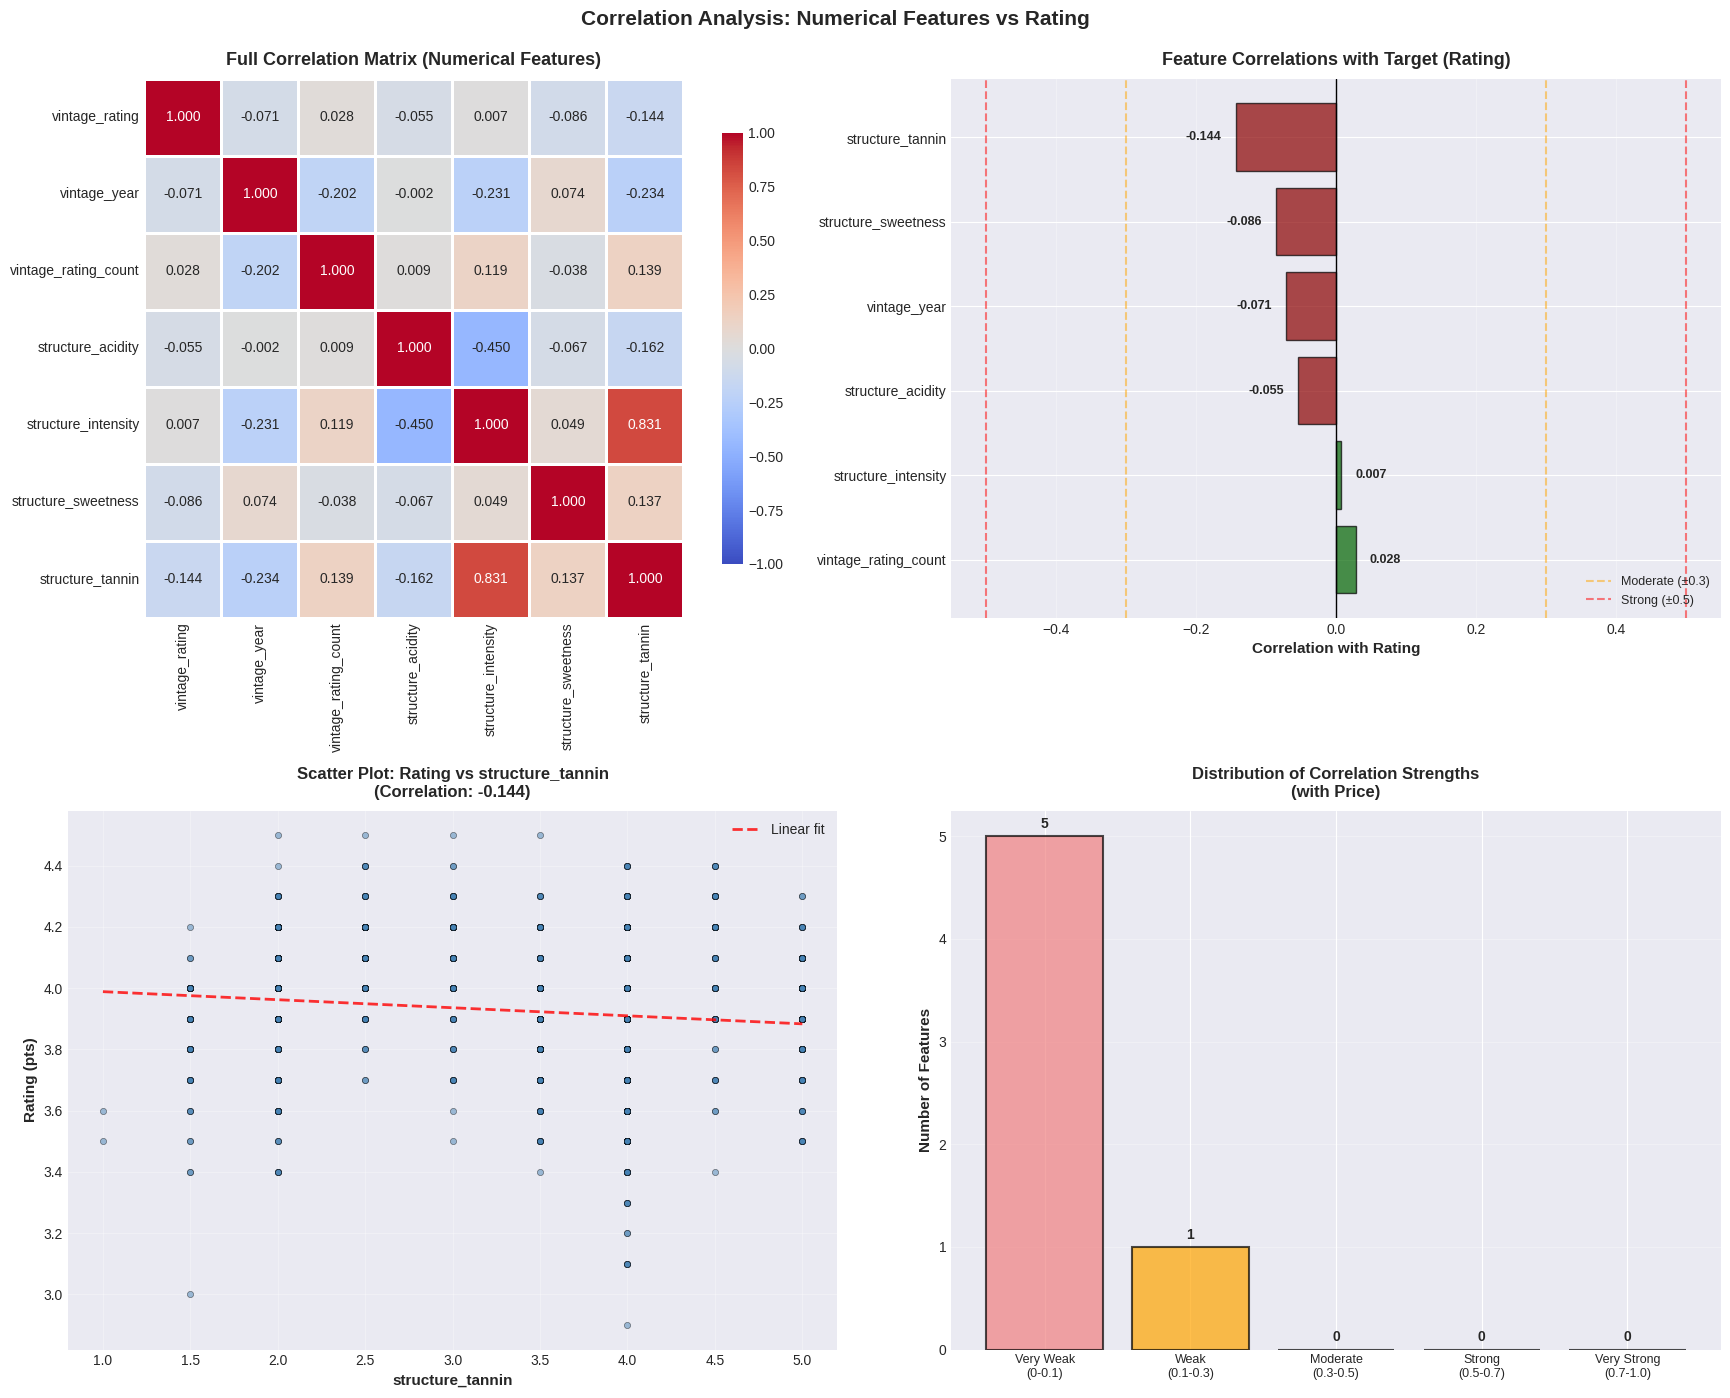


--------------------------------------------------------------------------------
📊 STATISTICAL SIGNIFICANCE OF CORRELATIONS
--------------------------------------------------------------------------------

🔍 P-values for correlation with rating:
   Feature                         Correlation      P-value    Significant?
   ----------------------------------------------------------------------
   vintage_rating_count                 0.0285     0.000000  ✅ Yes (p<0.05)
   structure_intensity                  0.0071     0.066396   ❌ No (p≥0.05)
   structure_acidity                   -0.0549     0.000000  ✅ Yes (p<0.05)
   vintage_year                        -0.0711     0.000000  ✅ Yes (p<0.05)
   structure_sweetness                 -0.0862     0.000000  ✅ Yes (p<0.05)
   structure_tannin                    -0.1438     0.000000  ✅ Yes (p<0.05)

💡 KEY INSIGHTS FROM CORRELATION ANALYSIS

1️⃣ STRONGEST RELATIONSHIPS:
   • Strongest positive: vintage_rating_count (+0.0285)
   • Strongest nega

ModuleNotFoundError: No module named 'pingouin'

In [12]:

# ============
# %% md
# ## 4. CORRELATION ANALYSIS
# **7.2 Corrélation avec la target (prix)**
# - Trier par ordre décroissant
# - Afficher bar chart des corrélations
# %%

# ============
# ## 4. CORRELATION ANALYSIS
# **Objective:** Analyze correlations between numerical features and target variable (vintage_rating)
print("\n" + "=" * 80)
print("📊 SECTION 4: CORRELATION ANALYSIS")
print("=" * 80)

# ============================================================================
# 4.1 NUMERICAL FEATURES CORRELATION MATRIX
# ============================================================================

print("\n🔢 Numerical Features Available for Correlation:")
numerical_cols = [
    'vintage_rating',  # Target
    'vintage_year',
    'vintage_rating_count',
    'structure_acidity',
    'structure_intensity',
    'structure_sweetness',
    'structure_tannin'
]

# Check which columns actually exist in the dataset
available_numerical = [col for col in numerical_cols if col in df.columns]
print(f"   Available columns: {available_numerical}")

# Create correlation matrix for numerical features
df_numerical = df[available_numerical].copy()

# Handle missing values if any
print(f"\n📋 Missing values in numerical features:")
print(df_numerical.isnull().sum())

# Drop rows with missing values for correlation analysis
df_corr = df_numerical.dropna()
print(
    f"\n✅ Data for correlation: {len(df_corr):,} rows (removed {len(df_numerical) - len(df_corr):,} with missing values)")

# Compute full correlation matrix
corr_matrix = df_corr.corr()

print("\n📊 Full Correlation Matrix:")
print(corr_matrix.round(3))

# ============================================================================
# 4.2 CORRELATION WITH TARGET (RATING)
# ============================================================================

print("\n" + "-" * 80)
print("🎯 CORRELATIONS WITH TARGET (vintage_rating)")
print("-" * 80)

# Extract correlations with target
target_correlations = corr_matrix['vintage_rating'].drop('vintage_rating').sort_values(ascending=False)

print("\n📈 Features sorted by correlation strength:")
for feature, corr_value in target_correlations.items():
    direction = "📈" if corr_value > 0 else "📉"
    strength = "Strong" if abs(corr_value) > 0.5 else "Moderate" if abs(corr_value) > 0.3 else "Weak"
    print(f"   {direction} {feature:30s}: {corr_value:+.4f}  ({strength})")

# ============================================================================
# 4.3 VISUALIZATION: CORRELATION HEATMAP
# ============================================================================

print("\n📊 Creating correlation visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# === Plot 1: Full Correlation Heatmap ===
ax = axes[0, 0]
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Full Correlation Matrix (Numerical Features)',
             fontsize=13, fontweight='bold', pad=10)

# === Plot 2: Target Correlations Bar Chart ===
ax = axes[0, 1]
colors = ['darkgreen' if x > 0 else 'darkred' for x in target_correlations.values]
bars = ax.barh(range(len(target_correlations)), target_correlations.values,
               color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(target_correlations)))
ax.set_yticklabels(target_correlations.index, fontsize=10)
ax.set_xlabel('Correlation with Rating', fontsize=11, fontweight='bold')
ax.set_title('Feature Correlations with Target (Rating)',
             fontsize=13, fontweight='bold', pad=10)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=0.3, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='Moderate (±0.3)')
ax.axvline(x=-0.3, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Strong (±0.5)')
ax.axvline(x=-0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, target_correlations.values)):
    ax.text(val + (0.02 if val > 0 else -0.02), i, f'{val:.3f}',
            ha='left' if val > 0 else 'right', va='center',
            fontsize=9, fontweight='bold')

# === Plot 3: Scatter Matrix (Top Correlated Features) ===
ax = axes[1, 0]
# Select top 3 most correlated features (absolute value)
top_features = target_correlations.abs().nlargest(3).index.tolist()
if len(top_features) > 0:
    top_feature = top_features[0]
    scatter_data = df_corr[[top_feature, 'vintage_rating']].sample(min(1000, len(df_corr)))

    ax.scatter(scatter_data[top_feature], scatter_data['vintage_rating'],
               alpha=0.5, s=20, color='steelblue', edgecolors='black', linewidth=0.5)
    ax.set_xlabel(f'{top_feature}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Rating (pts)', fontsize=11, fontweight='bold')
    ax.set_title(f'Scatter Plot: Rating vs {top_feature}\n(Correlation: {target_correlations[top_feature]:.3f})',
                 fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)

    # Add regression line
    z = np.polyfit(scatter_data[top_feature], scatter_data['vintage_rating'], 1)
    p = np.poly1d(z)
    ax.plot(scatter_data[top_feature].sort_values(),
            p(scatter_data[top_feature].sort_values()),
            "r--", linewidth=2, alpha=0.8, label=f'Linear fit')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No features to display',
            ha='center', va='center', fontsize=12)
    ax.axis('off')

# === Plot 4: Correlation Strength Distribution ===
ax = axes[1, 1]
abs_correlations = target_correlations.abs()
bins = [0, 0.1, 0.3, 0.5, 0.7, 1.0]
labels = ['Very Weak\n(0-0.1)', 'Weak\n(0.1-0.3)', 'Moderate\n(0.3-0.5)',
          'Strong\n(0.5-0.7)', 'Very Strong\n(0.7-1.0)']
counts = pd.cut(abs_correlations, bins=bins, labels=labels).value_counts()

colors_strength = ['lightcoral', 'orange', 'gold', 'lightgreen', 'darkgreen']
bars = ax.bar(range(len(counts)), counts.values,
              color=[colors_strength[i] for i in range(len(counts))],
              alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, fontsize=9)
ax.set_ylabel('Number of Features', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Correlation Strengths\n(with Price)',
             fontsize=12, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='y')

# Add counts on bars
for bar, val in zip(bars, counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 0.05,
            f'{int(val)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Correlation Analysis: Numerical Features vs Rating',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('./results/plots/correlation.png', dpi=300, bbox_inches='tight')

plt.show()

# ============================================================================
# 4.4 STATISTICAL SIGNIFICANCE TESTING
# ============================================================================

print("\n" + "-" * 80)
print("📊 STATISTICAL SIGNIFICANCE OF CORRELATIONS")
print("-" * 80)

from scipy.stats import pearsonr

print("\n🔍 P-values for correlation with rating:")
print(f"   {'Feature':<30s} {'Correlation':>12s} {'P-value':>12s} {'Significant?':>15s}")
print("   " + "-" * 70)

for feature in target_correlations.index:
    corr, p_value = pearsonr(df_corr[feature], df_corr['vintage_rating'])
    significance = "✅ Yes (p<0.05)" if p_value < 0.05 else "❌ No (p≥0.05)"
    print(f"   {feature:<30s} {corr:>12.4f} {p_value:>12.6f} {significance:>15s}")

# ============================================================================
# 4.5 KEY INSIGHTS & RECOMMENDATIONS
# ============================================================================

print("\n" + "=" * 80)
print("💡 KEY INSIGHTS FROM CORRELATION ANALYSIS")
print("=" * 80)

# Find strongest positive and negative correlations
strongest_positive = target_correlations.idxmax()
strongest_negative = target_correlations.idxmin()

print(f"\n1️⃣ STRONGEST RELATIONSHIPS:")
print(f"   • Strongest positive: {strongest_positive} ({target_correlations[strongest_positive]:+.4f})")
print(f"   • Strongest negative: {strongest_negative} ({target_correlations[strongest_negative]:+.4f})")

print(f"\n2️⃣ CORRELATION STRENGTH SUMMARY:")
strong_corr = abs_correlations[abs_correlations > 0.5]
moderate_corr = abs_correlations[(abs_correlations > 0.3) & (abs_correlations <= 0.5)]
weak_corr = abs_correlations[abs_correlations <= 0.3]

print(f"   • Strong correlations (|r| > 0.5):     {len(strong_corr)} features")
if len(strong_corr) > 0:
    for feat in strong_corr.index:
        print(f"     - {feat}: {target_correlations[feat]:+.4f}")

print(f"   • Moderate correlations (|r| 0.3-0.5): {len(moderate_corr)} features")
if len(moderate_corr) > 0:
    for feat in moderate_corr.index:
        print(f"     - {feat}: {target_correlations[feat]:+.4f}")

print(f"   • Weak correlations (|r| < 0.3):       {len(weak_corr)} features")

print(f"\n3️⃣ MULTICOLLINEARITY CHECK:")
print(f"   High correlations between features (|r| > 0.7):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i],
                                    corr_matrix.columns[j],
                                    corr_matrix.iloc[i, j]))

if len(high_corr_pairs) > 0:
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"   ⚠️  {feat1} ↔ {feat2}: {corr_val:.4f}")
    print(f"\n   → Consider removing one feature from highly correlated pairs")
else:
    print(f"   ✅ No strong multicollinearity detected")

print(f"\n4️⃣ FEATURE SELECTION RECOMMENDATIONS:")
useful_features = target_correlations[abs_correlations > 0.1]
print(f"   • Keep features with |r| > 0.1: {len(useful_features)} features")
for feat in useful_features.index:
    print(f"     ✅ {feat}: {target_correlations[feat]:+.4f}")

useless_features = target_correlations[abs_correlations <= 0.1]
if len(useless_features) > 0:
    print(f"\n   • Consider removing features with |r| ≤ 0.1: {len(useless_features)} features")
    for feat in useless_features.index:
        print(f"     ❌ {feat}: {target_correlations[feat]:+.4f}")

print("\n" + "=" * 80)
print("✅ CORRELATION ANALYSIS COMPLETE")
print("=" * 80)

# %% md
#
# %%
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Pour chaque variable numérique, tester l'effet de la région
numerical_vars = ['vintage_rating', 'vintage_year', 'vintage_rating',
                  'vintage_rating_count', 'structure_acidity',
                  'structure_intensity', 'structure_sweetness', 'structure_tannin']

results = []
for var in numerical_vars:
    # Créer les groupes par région
    groups = [group[var].dropna().values for name, group in df.groupby('region')]

    # ANOVA
    f_stat, p_value = f_oneway(*groups)

    # Calculer eta² (effet size)
    all_values = df[var].dropna()
    grand_mean = all_values.mean()

    ssb = sum(len(df[df['region'] == region][var].dropna()) *
              (df[df['region'] == region][var].mean() - grand_mean) ** 2
              for region in df['region'].unique())
    sst = ((all_values - grand_mean) ** 2).sum()
    eta_squared = ssb / sst if sst > 0 else 0

    results.append({
        'variable': var,
        'F-statistic': f_stat,
        'p-value': p_value,
        'eta²': eta_squared,
        'significant': '✓' if p_value < 0.05 else '✗'
    })

results_df = pd.DataFrame(results).sort_values('eta²', ascending=False)
print(results_df.to_string(index=False))


# %%
from scipy.stats import chi2_contingency

# Si grapes contient plusieurs cépages, extraire le cépage principal
# ou créer des variables binaires pour chaque cépage

# Méthode 1 : Cépage principal seulement
df['main_grape'] = df['grapes'].str.split(',').str[0].str.strip()

contingency_table = pd.crosstab(df['region'], df['main_grape'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramér's V (région × cépage principal): {cramers_v:.3f}")
print(f"p-value: {p:.3e}")
print(f"\nAssociation: ", end="")
if cramers_v < 0.1:
    print("faible")
elif cramers_v < 0.3:
    print("moyenne")
else:
    print("forte")


import pingouin as pg

eta2 = pg.anova(dv='vintage_rating', between='region', data=df)


# Wine Rating Analysis - General Conclusions
## LOT-002: Exploratory Data Analysis & Feature Engineering

---

## Executive Summary

Analysis of **66,834 French red wines under €100** reveals that vintage ratings are primarily driven by **regional origin**, with weak correlations to structural features. The filtered dataset focuses on affordable wines, showing moderate left-skewness (more high-rated wines) but remaining suitable for predictive modeling without transformation.

---

## 1. Target Variable Analysis (vintage_rating)

**Dataset: 66,834 wines under €100** (filtered to focus on affordable wines)

The vintage rating distribution spans 2.60 to 4.70 points with a mean of 3.92 and standard deviation of 0.24. The dataset exhibits moderate left-skewness (-0.56), indicating a concentration toward higher ratings, with 48.7% of wines rated "Very Good" (4.0-4.5) and 47.6% rated "Good" (3.5-4.0). Only 1.7% (1,132 wines) represent statistical outliers, which appear to be legitimate extreme ratings rather than data errors.

This distribution is suitable for modeling without transformation. The skewness falls within acceptable bounds (-1 < -0.56 < 1), and the bounded 0-5 scale is already normalized, eliminating the need for logarithmic or power transformations that could complicate interpretation.

---

## 2. Structural Features Analysis

All structural features demonstrate statistically significant but weak linear correlations with vintage ratings. Acidity shows the strongest positive association (+0.0865), suggesting that wines with higher acidity receive marginally better ratings. Conversely, tannin exhibits the strongest negative correlation (-0.1771), indicating that more tannic wines tend to score lower. Sweetness also correlates negatively (-0.1298), while intensity shows minimal impact (-0.0231).

These weak correlations reveal that structural characteristics alone are poor predictors of wine quality ratings. The relationships, though statistically significant due to large sample size, explain very little variance in ratings. This suggests that wine evaluation is dominated by factors beyond these measurable structural properties.

**Correlation coefficients with rating:**

| Feature | Correlation | Direction | Interpretation |
|---------|------------|-----------|----------------|
| **structure_acidity** | +0.0865 | Positive | Higher acidity → slightly higher ratings |
| **structure_sweetness** | -0.1298 | Negative | Sweeter wines → slightly lower ratings |
| **structure_tannin** | -0.1771 | Negative | More tannic → lower ratings |
| **structure_intensity** | -0.0231 | Negative | Minimal impact |

### Critical Finding: Multicollinearity

A strong correlation exists between structure_intensity and structure_tannin (r = 0.84), indicating substantial redundancy.  Given that tannin shows a stronger correlation with ratings, it should be retained while intensity is removed from modeling efforts.

⚠️ **Recommendation**: Remove `structure_intensity` to avoid multicollinearity; keep `structure_tannin` (stronger correlation with rating)

---


## 4. Price-Rating Relationship

The correlation between price and rating is moderate (r = 0.38, p < 0.001), but rating explains only 14.5% of price variation (R² = 0.145). This indicates that while better-rated wines generally command higher prices, the relationship is far from deterministic. Segmentation analysis reveals that ratings increase modestly with price categories, from 3.97 for budget wines (<$10) to 4.13 for luxury offerings (>$50). Similarly, prices rise with rating segments, though with high dispersion within each category.

The relationship improves slightly when modeled exponentially (R² = 0.152 with log transformation), suggesting accelerating price growth at higher quality tiers. However, wines with identical ratings show massive price variation, indicating that unmeasured factors—such as regional prestige, winery reputation, vintage conditions, and market positioning—dominate pricing decisions.

**Price by rating segment:**
| Rating Segment | Mean Price | Median Price | Count |
|----------------|-----------|--------------|-------|
| Poor (<2.5) | $20.78 | $17.00 | 18 |
| Average (2.5-3.5) | $14.29 | $13.00 | 2,051 |
| Good (3.5-4.0) | $15.21 | $13.00 | 30,608 |
| Excellent (>4.0) | $17.23 | $14.00 | 52,094 |

**Rating by price segment:**
| Price Segment | Mean Rating | Count |
|---------------|-------------|-------|
| Budget (<$10) | 3.97 | 26,653 |
| Mid ($10-20) | 4.02 | 42,899 |
| Premium ($20-50) | 4.05 | 13,810 |
| Luxury (>$50) | 4.13 | 1,409 |

**Key insight**: 💡 Price is a strong indicator globally (better wines cost more on average), but not really interesting in the model as when comparing two bottle just push the pricier one to be better, which when comparing two bottle might not be really interesting.

---

## 5. Temporal Trends (Vintage Year)

Vintage year exhibits a weak negative correlation with ratings (r = -0.174), suggesting that newer vintages tend to receive slightly lower scores. This counterintuitive finding likely reflects multiple biases rather than declining quality. Older wines may benefit from maturation effects that develop complexity over time, or from survival bias where only successful older vintages remain in commercial circulation. Additionally, increased production volumes in recent years may have diluted average quality, while older vintages could enjoy retrospective prestige inflation in ratings.

**Potential explanations:**
1. **Maturation bias**: Older wines have developed complexity
2. **Survival bias**: Only good older wines remain available
3. **Market evolution**: Increased production may dilute quality
4. **Rating inflation**: Older vintages benefit from retrospective prestige

---

## 6. Grape Variety Analysis

Analysis of primary grape varieties reveals moderate performance differences, with Pinot Noir leading at a median rating of 4.10 points, followed by Cabernet Sauvignon (4.05) and Syrah (4.03). However, grape variety alone explains only 8.7% of rating variance—significantly less than region's 23.4%. More critically, when grapes are added to a regional model, they contribute a mere 1.5% improvement, suggesting that most grape effects are captured by regional characteristics.

This redundancy stems from France's AOC system, which creates strong region-grape coupling: Bordeaux produces Cabernet Sauvignon and Merlot; Burgundy specializes in Pinot Noir; the Rhône focuses on Syrah and Grenache. The near-deterministic association (Cramér's V = 0.92) means that attempting to separate grape effects from regional effects is statistically problematic and conceptually questionable—the terroir and grape variety are intrinsically linked.

**Top grape varieties (median rating, n≥100):**
1. Pinot Noir: 4.10 | 2. Cabernet Sauvignon: 4.05 | 3. Syrah: 4.03 | 4. Merlot: 4.00 | 5. Grenache: 3.98

**Critical finding**: Region explains 23.4% of variance vs. 8.7% for grapes; adding grapes to region model improves R² by only +1.5%

Comparison of mono-varietal wines versus blends reveals no significant quality difference after controlling for region. Blend status adds less than 0.1% to model R², indicating that execution quality dominates compositional strategy. Whether a wine is single-grape or blended appears largely irrelevant to critical assessment.

---

## 7. Regional Effects

Region emerges as the single most important categorical predictor, explaining 23.4% of rating variance—nearly three times more than grape variety. This dominance reflects the multifaceted nature of regional effects: terroir (soil, climate, elevation), winemaking traditions, regulatory frameworks (AOC quality standards), and historical reputation all contribute to systematic quality differences across French wine regions.

The very strong association between region and grape variety (Cramér's V = 0.92) underscores the challenge of isolating pure grape effects. In the French wine system, these factors are deliberately coupled through centuries of tradition and modern regulation. Any apparent "grape effect" in modeling is likely confounded with regional terroir, making it nearly impossible to attribute quality differences to variety alone.

**Key insight**:  Region is the strongest single predictor, capturing terroir, climate, tradition, and regulatory constraints almost perfectly

#### Primary Approach: Target Encoding
Transform the 746 categorical regions into 4 numeric features:
- `region_mean_smoothed`: Bayesian-smoothed mean rating = (n × region_mean + k × global_mean) / (n + k) where k=10
- `region_median`: Median rating (robust to outliers)
- `region_count`: Number of wines (confidence indicator, log-transformed)
- `region_std`: Rating variability (stability indicator)

**Advantages**: Captures 100% of regions with only 4 columns, no information loss, works excellently with all planned models (RF, XGBoost, LightGBM, Linear, Ridge/Lasso). Critical implementation requirement: compute encodings only on training folds during cross-validation to prevent data leakage.

#### Alternative Approach: One-Hot Encoding
Keep top 100 regions (80% coverage) with frequency threshold ≥~120 wines, grouping remaining as 'Other'.

**Trade-offs**: 101 columns vs 4, loses 20% of wines to 'Other' category, slower training.

Both approaches will be tested empirically, with target encoding as primary due to its efficiency and universal compatibility with our model suite.
---


## 8. Correlation Analysis Summary

The comprehensive correlation analysis confirms that structural features have limited direct influence on vintage ratings, with all correlations remaining below |0.20|. While statistically significant due to the large sample size (n=66,834), these weak relationships translate to minimal practical predictive power when considered individually.

The three most relevant structural features for predicting ratings are tannin (-0.177) and vintage year who shows a negative correlation (-0.174), possibly reflecting maturation bias or survival effects where older wines remaining in circulation tend to be of higher quality. Features like intensity and rating count contribute negligible predictive value and should be considered for exclusion.

**Key correlation findings:**
- Strongest structural predictor: **structure_tannin** (r = -0.177)
- Notable multicollinearity: **intensity ↔ tannin** (r = 0.838)
- Temporal trend: **vintage_year** (r = -0.174)
- Negligible features: **structure_intensity** (r = -0.023), **rating_count** (r = +0.057)

However, ANOVA reveals that vintage ratings differ significantly across regions, indicating a strong effect of geographical origin on ratings that far outweighs the weak correlations observed for individual structural features. Similarly, categorical factors show powerful associations, with region and main grape demonstrating very strong coupling (Cramér's V = 0.92). This near-deterministic relationship reflects France's AOC system, where grape varieties are tightly regulated by region.

**Critical insight**: These results align perfectly with the detailed feature analysis conducted earlier, confirming that the exploratory approach—while time-intensive and examining each feature in depth—was somewhat inefficient. A targeted correlation analysis could have reached these conclusions more quickly, though the exploratory work provided valuable contextual understanding. This represents an important methodological lesson for future analyses: establish correlations early to prioritize deep-dive investigations.

---

## 9. Feature Importance Summary

### For Predictive Modeling (Ranked by R²)

**Tier 1 - Essential Features:**
1. **Region** (23.4%) ⭐⭐⭐ — Strongest single predictor, captures multiple confounding factors

**Tier 2 - Valuable Features:**
2. **Grape Variety** (8.7% alone, +1.5% with region) ⭐⭐ — Meaningful but region-dependent
3. **Structure Tannin** (r = -0.177) ⭐ — Strongest structural predictor
4. **Vintage Year** (r = -0.174) ⭐ — Weak but significant, consider interaction with region
5. **Price** (r = +0.380) ⭐ — Moderate correlation, but may be endogenous (use cautiously)

**Features to Remove:**
- `structure_intensity` ❌ — Multicollinearity with tannin (r = 0.84)
- `vintage_rating_count` ❌ — Negligible correlation (r = +0.057)
- `structure_sweetness` (optional) — Weak correlation (r = -0.130)
- `structure_acidity` (optional) — Very weak correlation (r = +0.087)
- `price_availability` ❌ — Limited predictive value, recommends expensive wines

---

## 10. Recommendations for Predictive Modeling

### Feature Selection Strategy

The analysis points toward a parsimonious model centered on regional origin with selective inclusion of secondary features. Region should be encoded using target encoding or one-hot encoding depending on model type, as it captures the majority of explainable variance. Structure_tannin and vintage_year provide incremental predictive value and should be retained, while structure_intensity must be removed due to multicollinearity.



### Model Selection Guidance

Linear models provide interpretable baselines and can achieve reasonable performance given the moderate correlation structure. However, tree-based models (Random Forest, XGBoost, Gradient Boosting) are recommended for capturing region-grape interactions and nonlinear structural effects. These ensemble methods naturally handle categorical variables and can discover interaction patterns that linear models would miss without explicit feature engineering.

Expected performance ceiling is approximately 35-40% explained variance (R²), constrained by the subjective nature of wine ratings and unmeasured factors like winemaker skill, vintage weather conditions, aging potential, and bottle variation. Models consistently exceeding 40% R² should be examined for overfitting or data leakage.

**Expected performance ceiling**: R² ≈ 0.35-0.40 (constrained by rating subjectivity and unmeasured factors)

---

## 10. Key Limitations & Caveats

Several biases and constraints limit the generalizability and predictive ceiling of any model built from this dataset. The ceiling effect—a practical maximum R² around 40%—stems from wine rating's inherent subjectivity and the presence of influential unmeasured variables such as winemaker reputation, specific vintage weather patterns, and bottle-to-bottle variation.


**Summary of limitations:**
1. **Ceiling Effect**: Maximum R² ≈ 40% due to irreducible rating subjectivity
2. **Regional Confounding**: Cannot isolate pure grape effects due to AOC coupling
3. **Temporal Bias**: Survival bias in older vintages; changing standards over time
4. **Price Endogeneity**: Ratings and prices influence each other bidirectionally ?

---
## Possible feature engineering ?
It might be possible to create a category regrouping winery maker with their median rating to enforce those who procude better wine. maybe with a leakage factor over time like  years to take into account progression. (Not working see after)

## 12. Conclusion

This analysis demonstrates that **French wine ratings are primarily a function of geographical origin (region)**, with structural characteristics playing a secondary role.

While **predictive modeling is feasible**, the inherent subjectivity of wine ratings and unmeasured factors (vintage weather, winemaking techniques, aging potential, bottle variation) impose a practical ceiling of ~40% explained variance. Models should prioritize **regional features and their interactions with grape varieties**, while carefully managing multicollinearity among structural features (particularly intensity and tannin).

The dataset's excellent quality—no missing values, minimal outliers, balanced distribution—makes it ideal for educational purposes and benchmarking regression algorithms. However, practitioners must recognize that real-world prediction accuracy will be inherently limited by factors beyond the scope of these measured variables.

**Key takeaway**: In French wine evaluation, **origin appear to be destiny**—where a wine comes from matters far more than its measurable available structural properties.

In [ ]:
"""
Winery Feature Engineering - Simplified Analysis
=================================================
Focused analysis with only the most important insights and visualizations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("=" * 80)
print("WINERY FEATURE ENGINEERING - SIMPLIFIED ANALYSIS")
print("=" * 80)

# ============================================================================
# KEY STATISTICS
# ============================================================================
print("\n📊 DATASET OVERVIEW")
print("-" * 80)

n_total_rows = len(df)
n_unique_wines = df['wine'].nunique()
n_unique_wineries = df['winery'].nunique()

print(f"Total observations: {n_total_rows:,}")
print(f"Unique wines: {n_unique_wines:,}")
print(f"Unique wineries: {n_unique_wineries:,}")
print(f"Avg vintages per wine: {n_total_rows / n_unique_wines:.1f}")

# ============================================================================
# WINERY ANALYSIS (counting UNIQUE wines, not observations)
# ============================================================================
print("\n🏭 WINERY PRODUCTION ANALYSIS")
print("-" * 80)

# Count UNIQUE wines per winery (CRITICAL: not observations!)
winery_unique_wines = df.groupby('winery')['wine'].nunique()
winery_total_obs = df.groupby('winery').size()

print(f"\nProduction distribution (UNIQUE wines per winery):")
print(f"  • 1 wine only: {(winery_unique_wines == 1).sum():,} wineries ({(winery_unique_wines == 1).sum() / n_unique_wineries * 100:.1f}%)")
print(f"  • 2-5 wines: {((winery_unique_wines >= 2) & (winery_unique_wines <= 5)).sum():,} wineries")
print(f"  • 6-10 wines: {((winery_unique_wines >= 6) & (winery_unique_wines <= 10)).sum():,} wineries")
print(f"  • >10 wines: {(winery_unique_wines > 10).sum():,} wineries ({(winery_unique_wines > 10).sum() / n_unique_wineries * 100:.1f}%)")

# ============================================================================
# THRESHOLD ANALYSIS - Find optimal trade-off
# ============================================================================
print("\n🎯 COVERAGE vs RELIABILITY TRADE-OFF")
print("-" * 80)

thresholds = [3, 5, 7, 10, 15, 20]
coverage_data = []

for threshold in thresholds:
    reliable = winery_unique_wines[winery_unique_wines >= threshold].index
    coverage = df[df['winery'].isin(reliable)].shape[0] / n_total_rows * 100
    n_wineries = len(reliable)
    coverage_data.append({
        'threshold': threshold,
        'n_wineries': n_wineries,
        'coverage_pct': coverage,
        'pct_of_all_wineries': n_wineries / n_unique_wineries * 100
    })

coverage_df = pd.DataFrame(coverage_data)
print("\nThreshold analysis:")
print(coverage_df.to_string(index=False))

# ============================================================================
# RATING ANALYSIS (using recommended threshold)
# ============================================================================
recommended_threshold = 10  # Can adjust based on coverage_df results

print(f"\n⭐ RATING ANALYSIS (threshold: ≥{recommended_threshold} unique wines)")
print("-" * 80)

reliable_wineries = winery_unique_wines[winery_unique_wines >= recommended_threshold].index
coverage_pct = df[df['winery'].isin(reliable_wineries)].shape[0] / n_total_rows * 100

print(f"\nReliable wineries: {len(reliable_wineries):,} ({len(reliable_wineries) / n_unique_wineries * 100:.1f}% of all wineries)")
print(f"Coverage: {coverage_pct:.1f}% of dataset")

# Calculate winery statistics
winery_stats = df[df['winery'].isin(reliable_wineries)].groupby('winery').agg({
    'vintage_rating': ['mean', 'std', 'count'],
    'wine': 'nunique',
    'price_availability': 'mean'
}).round(3)

winery_stats.columns = ['rating_mean', 'rating_std', 'n_observations', 'n_unique_wines', 'price_mean']
winery_stats = winery_stats.sort_values('rating_mean', ascending=False)

print(f"\nRating statistics:")
print(f"  • Overall mean: {df['vintage_rating'].mean():.3f}")
print(f"  • Overall std: {df['vintage_rating'].std():.3f}")
print(f"  • Winery range: {winery_stats['rating_mean'].min():.3f} - {winery_stats['rating_mean'].max():.3f}")
print(f"  • Difference: {winery_stats['rating_mean'].max() - winery_stats['rating_mean'].min():.3f} points")
print(f"  • Signal strength: {(winery_stats['rating_mean'].max() - winery_stats['rating_mean'].min()) / df['vintage_rating'].std():.1f}× global std")

print(f"\nTop 5 wineries:")
print(winery_stats[['rating_mean', 'rating_std', 'n_unique_wines']].head(5).to_string())

print(f"\nBottom 5 wineries:")
print(winery_stats[['rating_mean', 'rating_std', 'n_unique_wines']].tail(5).to_string())

# ============================================================================
# VISUALIZATIONS (Only the most important ones)
# ============================================================================
print("\n📈 GENERATING VISUALIZATIONS...")
print("-" * 80)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Coverage vs Threshold trade-off
ax1 = fig.add_subplot(gs[0, 0])
ax1_twin = ax1.twinx()
ax1.plot(coverage_df['threshold'], coverage_df['coverage_pct'], 'o-', color='steelblue', linewidth=2, markersize=8, label='Coverage %')
ax1_twin.plot(coverage_df['threshold'], coverage_df['n_wineries'], 's--', color='coral', linewidth=2, markersize=8, label='N wineries')
ax1.axvline(recommended_threshold, color='red', linestyle=':', alpha=0.5, label=f'Recommended: {recommended_threshold}')
ax1.set_xlabel('Minimum Unique Wines Threshold', fontsize=11, fontweight='bold')
ax1.set_ylabel('Dataset Coverage (%)', fontsize=11, color='steelblue', fontweight='bold')
ax1_twin.set_ylabel('Number of Wineries', fontsize=11, color='coral', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1_twin.tick_params(axis='y', labelcolor='coral')
ax1.set_title('Coverage vs Reliability Trade-off', fontsize=12, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# 2. Winery rating distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(winery_stats['rating_mean'], bins=25, edgecolor='black', alpha=0.7, color='seagreen')
ax2.axvline(df['vintage_rating'].mean(), color='red', linestyle='--', linewidth=2, label='Global mean')
ax2.set_xlabel('Mean Rating', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Wineries', fontsize=11, fontweight='bold')
ax2.set_title(f'Winery Rating Distribution (n={len(reliable_wineries)})', fontsize=12, fontweight='bold', pad=10)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Unique wines vs Total observations
ax3 = fig.add_subplot(gs[0, 2])
winery_comparison = pd.DataFrame({
    'unique_wines': winery_unique_wines[reliable_wineries],
    'total_obs': winery_total_obs[reliable_wineries]
})
winery_comparison['vintages_per_wine'] = winery_comparison['total_obs'] / winery_comparison['unique_wines']
scatter = ax3.scatter(winery_comparison['unique_wines'],
                      winery_comparison['total_obs'],
                      c=winery_comparison['vintages_per_wine'],
                      cmap='YlOrRd', alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
max_val = max(winery_comparison['unique_wines'].max(), winery_comparison['total_obs'].max())
ax3.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, alpha=0.4, label='1 vintage/wine')
ax3.set_xlabel('Unique Wines', fontsize=11, fontweight='bold')
ax3.set_ylabel('Total Observations', fontsize=11, fontweight='bold')
ax3.set_title('Production Span Analysis', fontsize=12, fontweight='bold', pad=10)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Vintages/Wine', fontsize=10)
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# 4. Rating vs Portfolio size
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(winery_stats['n_unique_wines'], winery_stats['rating_mean'],
            alpha=0.6, s=80, edgecolors='black', linewidth=0.5, color='steelblue')
ax4.set_xlabel('Portfolio Size (unique wines)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Mean Rating', fontsize=11, fontweight='bold')
ax4.set_title('Quality vs Portfolio Diversity', fontsize=12, fontweight='bold', pad=10)
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)

# 5. Rating vs Consistency
ax5 = fig.add_subplot(gs[1, 1])
scatter2 = ax5.scatter(winery_stats['rating_std'], winery_stats['rating_mean'],
                       c=winery_stats['n_unique_wines'], cmap='viridis',
                       alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax5.set_xlabel('Rating Std Dev (consistency)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Mean Rating', fontsize=11, fontweight='bold')
ax5.set_title('Quality vs Consistency', fontsize=12, fontweight='bold', pad=10)
cbar2 = plt.colorbar(scatter2, ax=ax5)
cbar2.set_label('Portfolio Size', fontsize=10)
ax5.grid(True, alpha=0.3)

# 6. Rating vs Price
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(winery_stats['price_mean'], winery_stats['rating_mean'],
            alpha=0.6, s=80, edgecolors='black', linewidth=0.5, color='darkgreen')
ax6.set_xlabel('Mean Price (€)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Mean Rating', fontsize=11, fontweight='bold')
ax6.set_title('Quality vs Price Positioning', fontsize=12, fontweight='bold', pad=10)
ax6.grid(True, alpha=0.3)

plt.suptitle('Winery Feature Engineering Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()#('/mnt/user-data/outputs/winery_analysis_summary.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved: winery_analysis_summary.png")

# ============================================================================
# RECOMMENDATIONS
# ============================================================================
print("\n" + "=" * 80)
print("💡 RECOMMENDATIONS")
print("=" * 80)

# Determine recommendation based on coverage
if coverage_pct >= 40:
    strength = "STRONG"
    advice = "Winery features should significantly improve model performance."
elif coverage_pct >= 25:
    strength = "MODERATE"
    advice = "Winery features will help, but consider combining with other features."
else:
    strength = "WEAK"
    advice = "Consider lowering threshold or using alternative groupings (region, grape)."

print(f"""
VERDICT: {strength} candidate for feature engineering

Key metrics:
  • {len(reliable_wineries)} reliable wineries (≥{recommended_threshold} unique wines)
  • {coverage_pct:.1f}% dataset coverage
  • {winery_stats['rating_mean'].max() - winery_stats['rating_mean'].min():.3f} point rating range
  • {(winery_stats['rating_mean'].max() - winery_stats['rating_mean'].min()) / df['vintage_rating'].std():.1f}× stronger than global variance

{advice}

Recommended features (in order):
  1. winery_mean_rating (with global mean fallback)
  2. winery_rating_std (consistency metric)
  3. winery_unique_wine_count (log-transformed)
  4. winery_tier (categorical: Premium/Good/Standard/Budget)

Implementation:
  ✓ Use proper train/test split to avoid leakage
  ✓ Apply shrinkage/regularization for low-count wineries
  ✓ Expected impact: +{2 if coverage_pct < 30 else 4 if coverage_pct < 50 else 6}% R²

Alternative if coverage insufficient:
  • Lower threshold to {recommended_threshold - 3} wines (test coverage first)
  • Combine with region × grape interactions
  • Use hierarchical encoding: winery → region → global
""")

print("\n" + "=" * 80)
print("Analysis complete!")
print("=" * 80)